In [1]:
import awkward as ak
import numpy as np
import matplotlib.pyplot as plt
import ROOT

In [ ]:
base_dir = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/Tuples_BKG_2024_condor_15GeV/merged/TTG1Jets-24SummerRun3/"

In [3]:
nominal = base_dir + 'nominal/diphoton/'

In [ ]:
material_up = base_dir + 'Material_up/diphoton'

In [5]:
material_down = base_dir + 'Material_down/diphoton'

In [6]:
Fnuf_up = base_dir + 'FNUF_up/diphoton'
ScaleEE2G_IJazZ_down = base_dir + 'ScaleEE2G_IJazZ_down/diphoton'
ScaleEE2G_IJazZ_up = base_dir + 'ScaleEE2G_IJazZ_up/diphoton'

In [7]:
Fnuf_down = base_dir + 'FNUF_down/diphoton'

In [ ]:
file = ak.from_parquet(nominal)

In [7]:
file_matup = ak.from_parquet(material_up)

In [8]:
file_matdown = ak.from_parquet(material_down)

In [9]:
file_fnufup = ak.from_parquet(Fnuf_up)

In [17]:
file_fndown = ak.from_parquet(Fnuf_down)
file_scaleEE2G_IJazZ_up = ak.from_parquet(ScaleEE2G_IJazZ_up)
file_scaleEE2G_IJazZ_down = ak.from_parquet(ScaleEE2G_IJazZ_down)

In [7]:
file_matup.fields

['pholead_cutBased',
 'pholead_electronVeto',
 'pholead_hasConversionTracks',
 'pholead_isScEtaEB',
 'pholead_isScEtaEE',
 'pholead_mvaID_WP80',
 'pholead_mvaID_WP90',
 'pholead_pixelSeed',
 'pholead_seedGain',
 'pholead_electronIdx',
 'pholead_jetIdx',
 'pholead_seediEtaOriX',
 'pholead_seediPhiOriY',
 'pholead_vidNestedWPBitmap',
 'pholead_ecalPFClusterIso',
 'pholead_energyErr',
 'pholead_energyRaw',
 'pholead_esEffSigmaRR',
 'pholead_esEnergyOverRawE',
 'pholead_eta',
 'pholead_etaWidth',
 'pholead_haloTaggerMVAVal',
 'pholead_hcalPFClusterIso',
 'pholead_hoe',
 'pholead_hoe_PUcorr',
 'pholead_hoe_Tower',
 'pholead_mvaID',
 'pholead_pfChargedIso',
 'pholead_pfChargedIsoPFPV',
 'pholead_pfChargedIsoWorstVtx',
 'pholead_pfPhoIso03',
 'pholead_pfRelIso03_all_quadratic',
 'pholead_pfRelIso03_chg_quadratic',
 'pholead_phi',
 'pholead_phiWidth',
 'pholead_r9',
 'pholead_s4',
 'pholead_sieie',
 'pholead_sieip',
 'pholead_sipip',
 'pholead_superclusterEta',
 'pholead_trkSumPtHollowConeDR03

In [8]:
file.fields

['pholead_cutBased',
 'pholead_electronVeto',
 'pholead_hasConversionTracks',
 'pholead_isScEtaEB',
 'pholead_isScEtaEE',
 'pholead_mvaID_WP80',
 'pholead_mvaID_WP90',
 'pholead_pixelSeed',
 'pholead_seedGain',
 'pholead_electronIdx',
 'pholead_jetIdx',
 'pholead_seediEtaOriX',
 'pholead_seediPhiOriY',
 'pholead_vidNestedWPBitmap',
 'pholead_ecalPFClusterIso',
 'pholead_energyErr',
 'pholead_energyRaw',
 'pholead_esEffSigmaRR',
 'pholead_esEnergyOverRawE',
 'pholead_eta',
 'pholead_etaWidth',
 'pholead_haloTaggerMVAVal',
 'pholead_hcalPFClusterIso',
 'pholead_hoe',
 'pholead_hoe_PUcorr',
 'pholead_hoe_Tower',
 'pholead_mvaID',
 'pholead_pfChargedIso',
 'pholead_pfChargedIsoPFPV',
 'pholead_pfChargedIsoWorstVtx',
 'pholead_pfPhoIso03',
 'pholead_pfRelIso03_all_quadratic',
 'pholead_pfRelIso03_chg_quadratic',
 'pholead_phi',
 'pholead_phiWidth',
 'pholead_r9',
 'pholead_s4',
 'pholead_sieie',
 'pholead_sieip',
 'pholead_sipip',
 'pholead_superclusterEta',
 'pholead_trkSumPtHollowConeDR03

In [36]:
file.pholead_pt

<Array [36.8, 33.6, 24.3, ... 26.3, 47.1, 24.1] type='1644 * ?float64'>

In [37]:
file.pholead_ScEta

<Array [-2.11, 1.34, 2.45, ... -1.76, 2.32] type='1644 * ?float32'>

In [38]:
file.pholead_r9

<Array [1.01, 0.994, 1.08, ... 1.01, 1.09] type='1644 * ?float32'>

In [45]:
Plot_dir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/"

In [46]:
ROOT.gStyle.SetOptStat(0)

import csv

# =========================
# Read CSV
# =========================

filename = "Miscellaneous/material_all_systematics.csv"

data = []

with open(filename) as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append({
            "systematic": row["systematic"],
            "eta_min": float(row["SCEta_min"]),
            "eta_max": float(row["SCEta_max"]),
            "r9_min": float(row["r9_min"]),
            "r9_max": float(row["r9_max"]),
            "Ecorr": float(row["Ecorr"])
        })

# =========================
# Extract helper
# =========================

def extract(systematic, low_r9=True):
    subset = [
        d for d in data
        if d["systematic"] == systematic
        and ((low_r9 and d["r9_max"] == 0.94) or
             (not low_r9 and d["r9_min"] == 0.94))
    ]

    subset = sorted(subset, key=lambda x: x["eta_min"])

    x, y = [], []
    for d in subset:
        eta_max = min(d["eta_max"], 2.5)
        eta_center = 0.5 * (d["eta_min"] + eta_max)
        x.append(eta_center)
        y.append(d["Ecorr"])

    return x, y


# =========================
# Build graph
# =========================

def make_graph(x, y, color, marker, linestyle=1):
    g = ROOT.TGraph(len(x))
    for i in range(len(x)):
        g.SetPoint(i, x[i], y[i])
    g.SetLineColor(color)
    g.SetMarkerColor(color)
    g.SetMarkerStyle(marker)
    g.SetLineWidth(2)
    g.SetLineStyle(linestyle)
    return g


# Extract all
x_up_low, y_up_low = extract("up", True)
x_up_high, y_up_high = extract("up", False)
x_down_low, y_down_low = extract("down", True)
x_down_high, y_down_high = extract("down", False)
x_def_low, y_def_low = extract("default", True)
x_def_high, y_def_high = extract("default", False)

g_up_low = make_graph(x_up_low, y_up_low, ROOT.kRed, 20)
g_up_high = make_graph(x_up_high, y_up_high, ROOT.kRed+2, 24)
g_down_low = make_graph(x_down_low, y_down_low, ROOT.kBlue, 21)
g_down_high = make_graph(x_down_high, y_down_high, ROOT.kBlue+2, 25)
g_def_low = make_graph(x_def_low, y_def_low, ROOT.kBlack, 23, 2)
g_def_high = make_graph(x_def_high, y_def_high, ROOT.kBlack, 26, 2)

# =========================
# Draw
# =========================

c = ROOT.TCanvas("c", "", 800, 600)
c.SetLeftMargin(0.15)

frame = ROOT.TH1F("frame", "", 100, 0, 2.6)
frame.SetMinimum(0.996)
frame.SetMaximum(1.004)
frame.GetXaxis().SetTitle("|#eta| bin center")
frame.GetYaxis().SetTitle("p_{T} correction factor")
frame.Draw()

# Reference line at 1
line = ROOT.TLine(0, 1.0, 2.6, 1.0)
line.SetLineStyle(2)
line.Draw()

# Draw graphs
g_def_low.Draw("PL SAME")
g_def_high.Draw("PL SAME")
g_up_low.Draw("PL SAME")
g_up_high.Draw("PL SAME")
g_down_low.Draw("PL SAME")
g_down_high.Draw("PL SAME")

leg = ROOT.TLegend(0.18, 0.62, 0.45, 0.88)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.028)

leg.AddEntry(g_def_low, "Default, R9 < 0.94", "lp")
leg.AddEntry(g_def_high, "Default, R9 #geq 0.94", "lp")
leg.AddEntry(g_up_low, "Up, R9 < 0.94", "lp")
leg.AddEntry(g_up_high, "Up, R9 #geq 0.94", "lp")
leg.AddEntry(g_down_low, "Down, R9 < 0.94", "lp")
leg.AddEntry(g_down_high, "Down, R9 #geq 0.94", "lp")

leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.78, 0.85, "Material")

c.Update()
c.SaveAs(Plot_dir+"material_systematics_plot.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/material_systematics_plot.png has been created


In [47]:
ROOT.gStyle.SetOptStat(0)

# =========================
# Read CSV
# =========================

filename = "Miscellaneous/fnuf_all_systematics.csv"

data = []

with open(filename) as f:
    reader = csv.DictReader(f)
    for row in reader:
        data.append({
            "systematic": row["systematic"],
            "eta_min": float(row["eta_min"]),
            "eta_max": float(row["eta_max"]),
            "r9_min": float(row["r9_min"]),
            "r9_max": float(row["r9_max"]),
            "Ecorr": float(row["value"])
        })

# =========================
# Extract helper
# =========================

def extract(systematic, low_r9=True):
    subset = [
        d for d in data
        if d["systematic"] == systematic
        and ((low_r9 and d["r9_max"] == 0.975) or
             (not low_r9 and d["r9_min"] == 0.975))
    ]

    subset = sorted(subset, key=lambda x: x["eta_min"])

    x, y = [], []
    for d in subset:
        eta_max = min(d["eta_max"], 7.0)
        eta_center = 0.5 * (d["eta_min"] + eta_max)
        x.append(eta_center)
        y.append(d["Ecorr"])

    return x, y


# =========================
# Build graph
# =========================

def make_graph(x, y, color, marker, linestyle=1):
    g = ROOT.TGraph(len(x))
    for i in range(len(x)):
        g.SetPoint(i, x[i], y[i])
    g.SetLineColor(color)
    g.SetMarkerColor(color)
    g.SetMarkerStyle(marker)
    g.SetLineWidth(2)
    g.SetLineStyle(linestyle)
    return g


# Extract all
x_up_low, y_up_low = extract("up", True)
x_up_high, y_up_high = extract("up", False)
x_down_low, y_down_low = extract("down", True)
x_down_high, y_down_high = extract("down", False)
x_def_low, y_def_low = extract("nominal", True)
x_def_high, y_def_high = extract("nominal", False)

g_up_low = make_graph(x_up_low, y_up_low, ROOT.kRed, 20)
g_up_high = make_graph(x_up_high, y_up_high, ROOT.kRed+2, 24)
g_down_low = make_graph(x_down_low, y_down_low, ROOT.kBlue, 21)
g_down_high = make_graph(x_down_high, y_down_high, ROOT.kBlue+2, 25)
g_def_low = make_graph(x_def_low, y_def_low, ROOT.kBlack, 23, 2)
g_def_high = make_graph(x_def_high, y_def_high, ROOT.kBlack, 26, 2)

# =========================
# Draw
# =========================

c = ROOT.TCanvas("c", "", 800, 600)
c.SetLeftMargin(0.15)

frame = ROOT.TH1F("frame", "", 100, 0, 4.5)
frame.SetMinimum(0.992)
frame.SetMaximum(1.008)
frame.GetXaxis().SetTitle("|#eta| bin center")
frame.GetYaxis().SetTitle("p_{T} correction factor")
frame.Draw()

# Reference line at 1
line = ROOT.TLine(0, 1.0, 4.5, 1.0)
line.SetLineStyle(2)
line.Draw()

# Draw graphs
g_def_low.Draw("PL SAME")
g_def_high.Draw("PL SAME")
g_up_low.Draw("PL SAME")
g_up_high.Draw("PL SAME")
g_down_low.Draw("PL SAME")
g_down_high.Draw("PL SAME")

leg = ROOT.TLegend(0.18, 0.62, 0.45, 0.90)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.022)

leg.AddEntry(g_def_low, "Nominal, R9 < 0.975", "lp")
leg.AddEntry(g_def_high, "Nominal, R9 #geq 0.975", "lp")
leg.AddEntry(g_up_low, "Up, R9 < 0.975", "lp")
leg.AddEntry(g_up_high, "Up, R9 #geq 0.975", "lp")
leg.AddEntry(g_down_low, "Down, R9 < 0.975", "lp")
leg.AddEntry(g_down_high, "Down, R9 #geq 0.975", "lp")

leg.Draw()

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.78, 0.85, "FNUF")

c.Update()
c.SaveAs(Plot_dir+"FNUF_systematics_plot.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Warning in <TROOT::Append>: Replacing existing TH1: frame (Potential memory leak).
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/FNUF_systematics_plot.png has been created


In [48]:
import csv

ROOT.gStyle.SetOptStat(0)

filename = "Miscellaneous/EGMSmearAndSyst_PhoPTsplit_20242G.csv"

data = []

# =========================
# Read CSV
# =========================
with open(filename, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["syst"] in ["smear", "smear_up", "smear_down"]:
            data.append({
                "type": row["syst"],
                "pt_min": float(row["pt_min"]),
                "pt_max": float(row["pt_max"]),
                "r9_min": round(float(row["r9_min"]), 3),
                "r9_max": round(float(row["r9_max"]), 3),
                "eta_min": round(float(row["AbsScEta_min"]), 3),
                "eta_max": round(float(row["AbsScEta_max"]), 3),
                "value": float(row["value"])
            })

# =========================
# Unique bins
# =========================
types = sorted(set(d["type"] for d in data))
eta_bins = sorted(set((d["eta_min"], d["eta_max"]) for d in data))
r9_bins = sorted(set((d["r9_min"], d["r9_max"]) for d in data))

# =========================
# Styling
# =========================
color_map = {
    "smear": ROOT.kBlack,
    "smear_up": ROOT.kRed,
    "smear_down": ROOT.kBlue
}

line_styles = {}
for i, r9 in enumerate(r9_bins):
    line_styles[r9] = 1 if i == 0 else 2  # solid / dashed

r9_labels = {}
for r9 in r9_bins:
    r9_min, r9_max = r9
    r9_labels[r9] = f"{r9_min:.2f} < R9 < {r9_max:.2f}"


# =========================
# Canvas
# =========================
c = ROOT.TCanvas("c", "", 1200, 900)
c.Divide(2, 2)


all_graphs = []  # IMPORTANT: store graphs to avoid GC

# =========================
# Loop over eta bins
# =========================

global_max = max(d["value"] for d in data)
global_min = min(d["value"] for d in data)

wanted_types = ["smear", "smear_up", "smear_down"]

# =========================
# Create legend ONCE
# =========================
leg = ROOT.TLegend(0.50, 0.50, 0.75, 0.85)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)


for i_eta, (eta_min, eta_max) in enumerate(eta_bins):

    pad = c.cd(i_eta + 1)
    pad.SetLeftMargin(0.08)
    pad.SetBottomMargin(0.08)
    pad.SetRightMargin(0.05)
    pad.SetTopMargin(0.05)
    pad.SetTicks(1, 1)

    pad.Modified()
    pad.Update()


    # Filter values for this eta bin
    valid_values = [
        d["value"] for d in data
        if d["eta_min"] == eta_min
        and d["eta_max"] == eta_max
    ]

    if not valid_values:
        continue

    ymax = max(valid_values) * 1.3

    # =========================
    # Create MultiGraph (correct axis handling)
    # =========================
    mg = ROOT.TMultiGraph()

    for t in wanted_types:

        if t not in types:
            continue

        for r9 in r9_bins:

            subset = [
                d for d in data
                if d["type"] == t
                and d["eta_min"] == eta_min
                and d["eta_max"] == eta_max
                and d["r9_min"] == r9[0]
                and d["r9_max"] == r9[1]
            ]

            if not subset:
                continue

            subset = sorted(subset, key=lambda x: x["pt_min"])

            g = ROOT.TGraph(len(subset))

            for i, d in enumerate(subset):
                pt_center = 0.5 * (d["pt_min"] + min(d["pt_max"], 200))
                g.SetPoint(i, pt_center, d["value"])

            g.SetLineColor(color_map[t])
            g.SetMarkerColor(color_map[t])
            g.SetLineStyle(line_styles[r9])
            g.SetLineWidth(1)
            g.SetMarkerStyle(20)
            g.SetMarkerSize(0.5)

            mg.Add(g)
            all_graphs.append(g)

            if i_eta == 0:
                label_type = {
                    "smear": "Nominal",
                    "smear_up": "Up",
                    "smear_down": "Down"
                }[t]

                label_r9 = r9_labels[r9]

                leg.AddEntry(g, f"{label_type} ({label_r9})", "lp")


    # ---- Draw multigraph ONCE ----
    mg.Draw("APL")

    mg.GetXaxis().SetTitle("Photon p_{T} bin center [GeV]")
    mg.GetYaxis().SetTitle("Smear")

    mg.SetMinimum(global_min * 1.1)
    mg.SetMaximum(global_max * 1.1)

    mg.GetXaxis().SetTitleSize(0.03)
    mg.GetYaxis().SetTitleSize(0.04)
    mg.GetXaxis().SetLabelSize(0.035)
    mg.GetYaxis().SetLabelSize(0.035)
    mg.GetXaxis().SetTitleOffset(1.2)
    mg.GetYaxis().SetTitleOffset(1.1)

    all_graphs.append(mg)

    # Eta label
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.05)
    latex.DrawLatex(0.20, 0.85,
        f"{eta_min} < |#eta| < {eta_max}")


    pad.RedrawAxis()
    pad.Modified()
    pad.Update()

# Draw legend once
c.cd(1)
leg.Draw()

c.Update()
c.SaveAs(Plot_dir+"smearing_multipad.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/smearing_multipad.png has been created


In [49]:
import csv

ROOT.gStyle.SetOptStat(0)

filename = "Miscellaneous/EGMSmearAndSyst_PhoPTsplit_20242G.csv"

data = []

wanted_types = ["mu"]

# =========================
# Read CSV
# =========================
with open(filename, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["syst"] in wanted_types:
            data.append({
                "type": row["syst"],
                "pt_min": float(row["pt_min"]),
                "pt_max": float(row["pt_max"]),
                "r9_min": round(float(row["r9_min"]), 3),
                "r9_max": round(float(row["r9_max"]), 3),
                "eta_min": round(float(row["AbsScEta_min"]), 3),
                "eta_max": round(float(row["AbsScEta_max"]), 3),
                "value": float(row["value"])
            })

# =========================
# Unique bins
# =========================
types = sorted(set(d["type"] for d in data))
eta_bins = sorted(set((d["eta_min"], d["eta_max"]) for d in data))
r9_bins = sorted(set((d["r9_min"], d["r9_max"]) for d in data))

# =========================
# Styling
# =========================
color_map = {
    "mu": ROOT.kBlack
}

line_styles = {}
for i, r9 in enumerate(r9_bins):
    line_styles[r9] = 1 if i == 0 else 2  # solid / dashed

r9_labels = {}
for r9 in r9_bins:
    r9_min, r9_max = r9
    r9_labels[r9] = f"{r9_min:.2f} < R9 < {r9_max:.2f}"


# =========================
# Canvas
# =========================
c = ROOT.TCanvas("c", "", 1200, 900)
c.Divide(2, 2)


all_graphs = []  # IMPORTANT: store graphs to avoid GC

# =========================
# Loop over eta bins
# =========================

global_max = max(d["value"] for d in data)
global_min = min(d["value"] for d in data)

# =========================
# Create legend ONCE
# =========================
leg = ROOT.TLegend(0.50, 0.50, 0.75, 0.65)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)


for i_eta, (eta_min, eta_max) in enumerate(eta_bins):

    pad = c.cd(i_eta + 1)
    pad.SetLeftMargin(0.08)
    pad.SetBottomMargin(0.08)
    pad.SetRightMargin(0.05)
    pad.SetTopMargin(0.05)
    pad.SetTicks(1, 1)

    pad.Modified()
    pad.Update()


    # Filter values for this eta bin
    valid_values = [
        d["value"] for d in data
        if d["eta_min"] == eta_min
        and d["eta_max"] == eta_max
    ]

    if not valid_values:
        continue

    ymax = max(valid_values) * 1.3

    # =========================
    # Create MultiGraph (correct axis handling)
    # =========================
    mg = ROOT.TMultiGraph()

    for t in wanted_types:

        if t not in types:
            continue

        for r9 in r9_bins:

            subset = [
                d for d in data
                if d["type"] == t
                and d["eta_min"] == eta_min
                and d["eta_max"] == eta_max
                and d["r9_min"] == r9[0]
                and d["r9_max"] == r9[1]
            ]

            if not subset:
                continue

            subset = sorted(subset, key=lambda x: x["pt_min"])

            g = ROOT.TGraph(len(subset))

            for i, d in enumerate(subset):
                pt_center = 0.5 * (d["pt_min"] + min(d["pt_max"], 200))
                g.SetPoint(i, pt_center, d["value"])

            g.SetLineColor(color_map[t])
            g.SetMarkerColor(color_map[t])
            g.SetLineStyle(line_styles[r9])
            g.SetLineWidth(1)
            g.SetMarkerStyle(20)
            g.SetMarkerSize(0.5)

            mg.Add(g)
            all_graphs.append(g)

            if i_eta == 0:
                label_type = {
                    "mu": "Nominal"
                }[t]

                label_r9 = r9_labels[r9]

                leg.AddEntry(g, f"{label_type} ({label_r9})", "lp")


    # ---- Draw multigraph ONCE ----
    mg.Draw("APL")

    mg.GetXaxis().SetTitle("Photon p_{T} bin center [GeV]")
    mg.GetYaxis().SetTitle("Mu")

    mg.SetMinimum(global_min * 1.1)
    mg.SetMaximum(global_max * 1.1)

    mg.GetXaxis().SetTitleSize(0.03)
    mg.GetYaxis().SetTitleSize(0.04)
    mg.GetXaxis().SetLabelSize(0.035)
    mg.GetYaxis().SetLabelSize(0.035)
    mg.GetXaxis().SetTitleOffset(1.2)
    mg.GetYaxis().SetTitleOffset(1.1)

    all_graphs.append(mg)

    # Eta label
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.05)
    latex.DrawLatex(0.20, 0.85,
        f"{eta_min} < |#eta| < {eta_max}")


    pad.RedrawAxis()
    pad.Modified()
    pad.Update()

# Draw legend once
c.cd(1)
leg.Draw()

c.Update()
c.SaveAs(Plot_dir+"mu_multipad.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/mu_multipad.png has been created


In [50]:
import csv

ROOT.gStyle.SetOptStat(0)

filename = "Miscellaneous/EGMSmearAndSyst_PhoPTsplit_20242G.csv"

data = []

wanted_types = ["frac"]

# =========================
# Read CSV
# =========================
with open(filename, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["syst"] in wanted_types:
            data.append({
                "type": row["syst"],
                "pt_min": float(row["pt_min"]),
                "pt_max": float(row["pt_max"]),
                "r9_min": round(float(row["r9_min"]), 3),
                "r9_max": round(float(row["r9_max"]), 3),
                "eta_min": round(float(row["AbsScEta_min"]), 3),
                "eta_max": round(float(row["AbsScEta_max"]), 3),
                "value": float(row["value"])
            })

# =========================
# Unique bins
# =========================
types = sorted(set(d["type"] for d in data))
eta_bins = sorted(set((d["eta_min"], d["eta_max"]) for d in data))
r9_bins = sorted(set((d["r9_min"], d["r9_max"]) for d in data))

# =========================
# Styling
# =========================
color_map = {
    "frac": ROOT.kBlack
}

line_styles = {}
for i, r9 in enumerate(r9_bins):
    line_styles[r9] = 1 if i == 0 else 2  # solid / dashed

r9_labels = {}
for r9 in r9_bins:
    r9_min, r9_max = r9
    r9_labels[r9] = f"{r9_min:.2f} < R9 < {r9_max:.2f}"


# =========================
# Canvas
# =========================
c = ROOT.TCanvas("c", "", 1200, 900)
c.Divide(2, 2)


all_graphs = []  # IMPORTANT: store graphs to avoid GC

# =========================
# Loop over eta bins
# =========================

global_max = max(d["value"] for d in data)
global_min = min(d["value"] for d in data)

# =========================
# Create legend ONCE
# =========================
leg = ROOT.TLegend(0.50, 0.50, 0.75, 0.65)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)


for i_eta, (eta_min, eta_max) in enumerate(eta_bins):

    pad = c.cd(i_eta + 1)
    pad.SetLeftMargin(0.08)
    pad.SetBottomMargin(0.08)
    pad.SetRightMargin(0.05)
    pad.SetTopMargin(0.05)
    pad.SetTicks(1, 1)

    pad.Modified()
    pad.Update()


    # Filter values for this eta bin
    valid_values = [
        d["value"] for d in data
        if d["eta_min"] == eta_min
        and d["eta_max"] == eta_max
    ]

    if not valid_values:
        continue

    ymax = max(valid_values) * 1.3

    # =========================
    # Create MultiGraph (correct axis handling)
    # =========================
    mg = ROOT.TMultiGraph()

    for t in wanted_types:

        if t not in types:
            continue

        for r9 in r9_bins:

            subset = [
                d for d in data
                if d["type"] == t
                and d["eta_min"] == eta_min
                and d["eta_max"] == eta_max
                and d["r9_min"] == r9[0]
                and d["r9_max"] == r9[1]
            ]

            if not subset:
                continue

            subset = sorted(subset, key=lambda x: x["pt_min"])

            g = ROOT.TGraph(len(subset))

            for i, d in enumerate(subset):
                pt_center = 0.5 * (d["pt_min"] + min(d["pt_max"], 200))
                g.SetPoint(i, pt_center, d["value"])

            g.SetLineColor(color_map[t])
            g.SetMarkerColor(color_map[t])
            g.SetLineStyle(line_styles[r9])
            g.SetLineWidth(1)
            g.SetMarkerStyle(20)
            g.SetMarkerSize(0.5)

            mg.Add(g)
            all_graphs.append(g)

            if i_eta == 0:
                label_type = {
                    "frac": "Nominal"
                }[t]

                label_r9 = r9_labels[r9]

                leg.AddEntry(g, f"{label_type} ({label_r9})", "lp")


    # ---- Draw multigraph ONCE ----
    mg.Draw("APL")

    mg.GetXaxis().SetTitle("Photon p_{T} bin center [GeV]")
    mg.GetYaxis().SetTitle("Frac")

    # mg.SetMinimum(global_min * 1.1)
    # mg.SetMaximum(global_max * 1.1)

    margin = 0.1 * (global_max - global_min)

    mg.SetMinimum(global_min - margin)
    mg.SetMaximum(global_max + margin)


    mg.GetXaxis().SetTitleSize(0.03)
    mg.GetYaxis().SetTitleSize(0.04)
    mg.GetXaxis().SetLabelSize(0.035)
    mg.GetYaxis().SetLabelSize(0.035)
    mg.GetXaxis().SetTitleOffset(1.2)
    mg.GetYaxis().SetTitleOffset(1.1)

    all_graphs.append(mg)

    # Eta label
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.05)
    latex.DrawLatex(0.68, 0.15,
        f"{eta_min} < |#eta| < {eta_max}")


    pad.RedrawAxis()
    pad.Modified()
    pad.Update()

# Draw legend once
c.cd(1)
leg.Draw()

c.Update()
c.SaveAs(Plot_dir+"frac_multipad.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/frac_multipad.png has been created


In [51]:
import csv

ROOT.gStyle.SetOptStat(0)

filename = "Miscellaneous/EGMSmearAndSyst_PhoPTsplit_20242G.csv"

data = []

wanted_types = ["reso_scale"]

# =========================
# Read CSV
# =========================
with open(filename, encoding="utf-8-sig") as f:
    reader = csv.DictReader(f)

    for row in reader:
        if row["syst"] in wanted_types:
            data.append({
                "type": row["syst"],
                "pt_min": float(row["pt_min"]),
                "pt_max": float(row["pt_max"]),
                "r9_min": round(float(row["r9_min"]), 3),
                "r9_max": round(float(row["r9_max"]), 3),
                "eta_min": round(float(row["AbsScEta_min"]), 3),
                "eta_max": round(float(row["AbsScEta_max"]), 3),
                "value": float(row["value"])
            })

# =========================
# Unique bins
# =========================
types = sorted(set(d["type"] for d in data))
eta_bins = sorted(set((d["eta_min"], d["eta_max"]) for d in data))
r9_bins = sorted(set((d["r9_min"], d["r9_max"]) for d in data))

# =========================
# Styling
# =========================
color_map = {
    "reso_scale": ROOT.kBlack
}

line_styles = {}
for i, r9 in enumerate(r9_bins):
    line_styles[r9] = 1 if i == 0 else 2  # solid / dashed

r9_labels = {}
for r9 in r9_bins:
    r9_min, r9_max = r9
    r9_labels[r9] = f"{r9_min:.2f} < R9 < {r9_max:.2f}"


# =========================
# Canvas
# =========================
c = ROOT.TCanvas("c", "", 1200, 900)
c.Divide(2, 2)


all_graphs = []  # IMPORTANT: store graphs to avoid GC

# =========================
# Loop over eta bins
# =========================

global_max = max(d["value"] for d in data)
global_min = min(d["value"] for d in data)

# =========================
# Create legend ONCE
# =========================
leg = ROOT.TLegend(0.15, 0.70, 0.25, 0.85)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.SetTextSize(0.035)


for i_eta, (eta_min, eta_max) in enumerate(eta_bins):

    pad = c.cd(i_eta + 1)
    pad.SetLeftMargin(0.08)
    pad.SetBottomMargin(0.08)
    pad.SetRightMargin(0.05)
    pad.SetTopMargin(0.05)
    pad.SetTicks(1, 1)

    pad.Modified()
    pad.Update()


    # Filter values for this eta bin
    valid_values = [
        d["value"] for d in data
        if d["eta_min"] == eta_min
        and d["eta_max"] == eta_max
    ]

    if not valid_values:
        continue

    ymax = max(valid_values) * 1.3

    # =========================
    # Create MultiGraph (correct axis handling)
    # =========================
    mg = ROOT.TMultiGraph()

    for t in wanted_types:

        if t not in types:
            continue

        for r9 in r9_bins:

            subset = [
                d for d in data
                if d["type"] == t
                and d["eta_min"] == eta_min
                and d["eta_max"] == eta_max
                and d["r9_min"] == r9[0]
                and d["r9_max"] == r9[1]
            ]

            if not subset:
                continue

            subset = sorted(subset, key=lambda x: x["pt_min"])

            g = ROOT.TGraph(len(subset))

            for i, d in enumerate(subset):
                pt_center = 0.5 * (d["pt_min"] + min(d["pt_max"], 200))
                g.SetPoint(i, pt_center, d["value"])

            g.SetLineColor(color_map[t])
            g.SetMarkerColor(color_map[t])
            g.SetLineStyle(line_styles[r9])
            g.SetLineWidth(1)
            g.SetMarkerStyle(20)
            g.SetMarkerSize(0.5)

            mg.Add(g)
            all_graphs.append(g)

            if i_eta == 0:
                label_type = {
                    "reso_scale": "Nominal"
                }[t]

                label_r9 = r9_labels[r9]

                leg.AddEntry(g, f"{label_type} ({label_r9})", "lp")


    # ---- Draw multigraph ONCE ----
    mg.Draw("APL")

    mg.GetXaxis().SetTitle("Photon p_{T} bin center [GeV]")
    mg.GetYaxis().SetTitle("Reso_scale")

    # mg.SetMinimum(global_min * 1.1)
    # mg.SetMaximum(global_max * 1.1)

    margin = 0.1 * (global_max - global_min)

    mg.SetMinimum(global_min - margin)
    mg.SetMaximum(global_max + margin)


    mg.GetXaxis().SetTitleSize(0.03)
    mg.GetYaxis().SetTitleSize(0.035)
    mg.GetXaxis().SetLabelSize(0.035)
    mg.GetYaxis().SetLabelSize(0.035)
    mg.GetXaxis().SetTitleOffset(1.2)
    mg.GetYaxis().SetTitleOffset(1.1)

    all_graphs.append(mg)

    # Eta label
    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextSize(0.05)
    latex.DrawLatex(0.68, 0.15,
        f"{eta_min} < |#eta| < {eta_max}")


    pad.RedrawAxis()
    pad.Modified()
    pad.Update()

# Draw legend once
c.cd(1)
leg.Draw()

c.Update()
c.SaveAs(Plot_dir+"Reso_scale_multipad.png")


Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Reso_scale_multipad.png has been created


In [52]:
def create_multipad_plot():
    # 1. Create a Canvas
    # Arguments: Name, Title, Width, Height
    c1 = ROOT.TCanvas("c1", "My 2x2 Multipad Canvas", 800, 800)
    
    # 2. Divide the Canvas into a 2x2 grid
    c1.Divide(2, 2)
    
    # Create histograms to fill the pads
    h1 = ROOT.TH1F("h1", "Pad 1: Gaussian", 100, -4, 4)
    h2 = ROOT.TH1F("h2", "Pad 2: Landau", 100, -5, 20)
    h3 = ROOT.TH1F("h3", "Pad 3: Exponential", 100, 0, 10)
    h4 = ROOT.TH2F("h4", "Pad 4: 2D Gaussian", 50, -3, 3, 50, -3, 3)

    # Fill histograms with random data
    for i in range(10000):
        h1.Fill(ROOT.gRandom.Gaus(0, 1))
        h2.Fill(ROOT.gRandom.Landau(0, 1))
        h3.Fill(ROOT.gRandom.Exp(2))
        h4.Fill(ROOT.gRandom.Gaus(0, 1), ROOT.gRandom.Gaus(0, 1))

    # 3. Access specific pads and draw
    # Note: ROOT pads are indexed starting from 1 (Top-Left is 1)
    
    # --- Pad 1 ---
    c1.cd(1)          # Switch focus to the first pad
    h1.SetFillColor(ROOT.kBlue - 9)
    h1.Draw()

    # --- Pad 2 ---
    c1.cd(2)
    h2.SetFillColor(ROOT.kRed - 9)
    h2.Draw()

    # --- Pad 3 ---
    c1.cd(3)
    h3.SetFillColor(ROOT.kGreen - 9)
    h3.Draw()

    # --- Pad 4 ---
    c1.cd(4)
    h4.Draw("COLZ")   # Draw 2D histo with color map

    # 4. Update and Save
    c1.Update()
    
    # Keep the window open (essential for scripts)
    input("Press Enter to quit...")

    c1.SaveAs("test_multipad.png")
    
    # Optionally save to file
    # c1.SaveAs("multipad_plot.png")

# if __name__ == "__main__":
#     create_multipad_plot()

In [53]:
create_multipad_plot()

Info in <TCanvas::Print>: png file test_multipad.png has been created


In [9]:
import pandas as pd
import numpy as np

df = pd.read_csv("Miscellaneous/material_all_systematics.csv")

In [10]:
raw_file = '/eos/user/b/bbapi/MC_contacts/2024_signal_samples_WH/CMSSW_15_0_15/src/WH_2024_M60.root'

In [11]:
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
factory = NanoEventsFactory.from_root(
    f"{raw_file}:Events",
    schemaclass=NanoAODSchema,
)
raw_events = factory.events()

In [53]:
print(df.columns)
print(df.head())

Index(['systematic', 'SCEta_min', 'SCEta_max', 'r9_min', 'r9_max', 'Ecorr'], dtype='object')
  systematic  SCEta_min  SCEta_max  r9_min  r9_max     Ecorr
0         up        0.0        1.0    0.00    0.94  1.000455
1         up        0.0        1.0    0.94  999.00  1.000233
2         up        1.0        1.5    0.00    0.94  1.002089
3         up        1.0        1.5    0.94  999.00  1.002089
4         up        1.5      999.0    0.00    0.94  1.001090


In [75]:
fp.pt

<Array [[37, 30.6], [...], ..., [36.3, 23.2]] type='4114 * var * float32[pa...'>

In [78]:
lead_photon.pt

<Array [37, 85, 54.6, ..., 26.2, 46.8, 36.3] type='4114 * float32[parameter...'>

In [79]:
sublead_photon.pt

<Array [30.6, 19.3, 25.4, ..., 26.6, 23.2] type='4114 * float32[parameters=...'>

In [12]:
def photon_scale_from_csv(
    ScEta,
    r9,
    syst,
    df
):
    ScEta = abs(ScEta)

    # Start with default = 1.0
    scale = ak.ones_like(ScEta, dtype=float)

    sub = df[df["systematic"] == syst]

    for _, row in sub.iterrows():
        mask = (
            (ScEta >= row.SCEta_min) & (ScEta < row.SCEta_max) &
            (r9    >= row.r9_min)    & (r9    < row.r9_max)
        )
        scale = ak.where(mask, row.Ecorr, scale)

    return scale


In [92]:
raw_events.Photon.fields

['cutBased',
 'electronVeto',
 'hasConversionTracks',
 'isScEtaEB',
 'isScEtaEE',
 'mvaID_WP80',
 'mvaID_WP90',
 'pixelSeed',
 'seedGain',
 'electronIdx',
 'jetIdx',
 'seediEtaOriX',
 'seediPhiOriY',
 'vidNestedWPBitmap',
 'ecalPFClusterIso',
 'energyErr',
 'energyRaw',
 'esEffSigmaRR',
 'esEnergyOverRawE',
 'eta',
 'etaWidth',
 'haloTaggerMVAVal',
 'hcalPFClusterIso',
 'hoe',
 'hoe_PUcorr',
 'hoe_Tower',
 'mvaID',
 'pfChargedIso',
 'pfChargedIsoPFPV',
 'pfChargedIsoWorstVtx',
 'pfPhoIso03',
 'pfRelIso03_all_quadratic',
 'pfRelIso03_chg_quadratic',
 'phi',
 'phiWidth',
 'pt',
 'r9',
 's4',
 'sieie',
 'sieip',
 'sipip',
 'superclusterEta',
 'trkSumPtHollowConeDR03',
 'trkSumPtSolidConeDR04',
 'x_calo',
 'y_calo',
 'z_calo',
 'genPartFlav',
 'genPartIdx',
 'electronIdxG',
 'genPartIdxG',
 'jetIdxG']

In [13]:
original_events = ak.copy(raw_events)

In [14]:
counts = ak.num(raw_events.Photon.pt)
eta = ak.flatten(abs(raw_events.Photon.superclusterEta))
r9 = ak.flatten(raw_events.Photon.r9)
_pt = ak.flatten(raw_events.Photon.pt)

scale_up = photon_scale_from_csv(
    eta,
    r9,
    "up",
    df
)

# scale_down = photon_scale_from_csv(
#     file.pholead_ScEta,
#     file.pholead_r9,
#     "down",
#     df)

# nominal = photon_scale_from_csv(
#     eta,
#     r9,
#     "default",
#     df)

corr_pt   = _pt * scale_up

corrected_photons = raw_events.Photon
corr_pt = ak.unflatten(corr_pt, counts)
corrected_photons["pt"] = corr_pt
raw_events["Photon"] = corrected_photons

In [25]:
ak.all(scale_up >1)

True

In [30]:
scale_up[2]

1.002377

In [27]:
_pt

<Array [66, 37.6, 13.3, ..., 191, 174, 99.1] type='633522 * float32[paramet...'>

In [28]:
eta

<Array [0.612, 0.0262, 2.04, ..., 0.807, 0.664] type='633522 * float32[para...'>

In [29]:
r9

<Array [0.744, 1, 1.03, ..., 0.968, 0.886] type='633522 * float32[parameter...'>

In [15]:
raw_events.Photon.pt

<Array [[66.1, 37.6, 13.3], ..., [191, ...]] type='280000 * var * float64'>

In [16]:
original_events.Photon.pt*1

<Array [[66, 37.6, 13.3], ..., [191, ...]] type='280000 * var * float32[par...'>

In [17]:
import awkward as ak
import numpy as np

def delta_r_manual(obj1, obj2):
    deta = obj1.eta[:, None] - obj2.eta
    dphi = np.abs(obj1.phi[:, None] - obj2.phi)
    dphi = ak.where(dphi > np.pi, 2 * np.pi - dphi, dphi)
    return np.sqrt(deta**2 + dphi**2)

def photon_preselections(
    photons: ak.Array,
    jets: ak.Array,
    electrons: ak.Array,
    muons: ak.Array,
    events: ak.Array,
    electron_veto=True,
    revert_electron_veto=False,
    year="2018",
    wp_medium=0.2783,
    IsFlag=False):
    """
    Apply full preselection on leptons, jets, and photons.
    Finally return only photons from events that pass all criteria.
    """

    print("Number of events before preselection:", len(events))

    # ------------------------
    # Lepton selection
    # ------------------------
    if year.startswith("2016"):
        ele_pt_cut, mu_pt_cut = 27, 26
    elif year == "2017":
        ele_pt_cut, mu_pt_cut = 33, 29
    elif year == "2018":
        # ele_pt_cut, mu_pt_cut = 33, 26
        ele_pt_cut, mu_pt_cut = 33, 26
    elif year == "2024":
        # ele_pt_cut, mu_pt_cut = 33, 26
        ele_pt_cut, mu_pt_cut = 30, 24

    else:
        raise ValueError(f"Unknown year {year}")

    # electrons = events.Electron

    good_electrons = (
        (electrons.pt > ele_pt_cut) &
        (np.abs(electrons.eta) < 2.5) &  # keep within tracker acceptance
        ~((np.abs(electrons.eta) > 1.44) & (np.abs(electrons.eta) < 1.57)) &  # remove transition
        (electrons.mvaIso_WP80) &        # tight MVA ID
        (electrons.pfRelIso03_all < 0.15)  # isolation cut
    )

    good_muons = (
        (muons.pt > mu_pt_cut)
        & (np.abs(muons.eta) < 2.4)
        & (muons.pfRelIso03_all < 0.15)
    )

    one_ele = ak.num(electrons[good_electrons]) == 1
    one_mu = ak.num(muons[good_muons]) == 1
    lepton_channel_mask = one_ele | one_mu
    # lepton_channel_mask = one_mu

    selected_electrons = electrons[good_electrons]
    print("selected_electrons", len(selected_electrons[ak.num(selected_electrons.pt)>0]))
    selected_muons = muons[good_muons]
    print("selected_muons", len(selected_muons[ak.num(selected_muons.pt)>0]))
    selected_leptons = ak.concatenate([selected_electrons, selected_muons], axis=1)
    print("selected_leptons", len(selected_leptons[ak.num(selected_leptons.pt)>0]))
    print("selected Electrons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==11])>0]))
    print("selected Muons", len(selected_leptons[ak.num(selected_leptons[abs(selected_leptons.pdgId)==13])>0]))

    # ------------------------
    # Jet selection
    # ------------------------
    good_jets = (
        (jets.pt > 20)
        & (np.abs(jets.eta) < 2.4)
        & (jets.btagUParTAK4B > 0.1272)
    )
    selected_bjets = jets[good_jets] 
    print("selected_b_jets: ", selected_bjets)
    at_least_two_bjets = ak.num(selected_bjets) >= 2

    # keep top 2 by DeepJet score
    # top2_bjets = selected_jets[ak.argsort(selected_jets.btagDeepFlavB, ascending=False)][:, :2]

    # ------------------------
    # Photon selection (from photon_preselection output)
    # ------------------------

    abs_eta = np.abs(photons.eta)

    # Barrel–endcap transition exclusion (1.442 ≤ |η| ≤ 1.566)
    valid_eta = (abs_eta <= 2.5) & ~((abs_eta >= 1.442) & (abs_eta <= 1.566))

    # Barrel vs Endcap ID cuts
    is_barrel = abs_eta < 1.442
    is_endcap = (abs_eta > 1.566) & (abs_eta < 2.5)

    # Apply region-specific MVA thresholds
    barrel_cut = is_barrel & (photons.mvaID > -0.02)
    endcap_cut = is_endcap & (photons.mvaID > -0.26)

    # Combine everything
    good_photons = (
        (photons.pt > 10)
        & valid_eta
        & (barrel_cut | endcap_cut)
        & (~photons.pixelSeed)
    )
    selected_photons = photons[good_photons]
    at_least_two_photons = ak.num(selected_photons) >= 2

    dr = delta_r_manual(selected_leptons, selected_photons)
    dr_mask = ak.all(ak.all(dr > 0.4, axis=-1), axis=-1)

    # ΔR between electrons and photons
    dr_electrons = delta_r_manual(selected_electrons, selected_photons)

    # ΔR between muons and photons
    dr_muons = delta_r_manual(selected_muons, selected_photons)


    event_mask = lepton_channel_mask & at_least_two_bjets & at_least_two_photons & dr_mask

    # ------------------------
    # Apply mask — keep length same, empties for failed events
    # ------------------------
    empty_photons = ak.Array([[]] * len(events))
    empty_bjets = ak.Array([[]] * len(events))
    empty_leptons = ak.Array([[]] * len(events))

    filtered_photons = ak.where(event_mask, selected_photons, empty_photons)
    filtered_jets = ak.where(event_mask, selected_bjets, empty_bjets)
    filtered_leptons = ak.where(event_mask, selected_leptons, empty_leptons)

    return event_mask, filtered_photons, filtered_jets, filtered_leptons

In [18]:
evt_mask, fp, fj, fl = photon_preselections(raw_events.Photon, raw_events.Jet, raw_events.Electron, raw_events.Muon, raw_events, year="2024")

Number of events before preselection: 280000


selected_electrons 46025
selected_muons 68702
selected_leptons 113264
selected Electrons 46025
selected Muons 68702
selected_b_jets:  [[{chMultiplicity: ??, nConstituents: ??, nElectrons: ??, ...}], ..., [{...}]]


In [19]:
fp = fp[ak.num(fp.pt)>0]

sorted_photons = fp[ak.argsort(fp.pt, axis=1, ascending=False)]

lead_photon     = sorted_photons[:, 0]
sublead_photon  = sorted_photons[:, 1]

In [20]:
lead_photon.pt

<Array [37.1, 85.2, 54.6, 40, ..., 26.2, 46.9, 36.4] type='4114 * float64'>

In [21]:
file_matup.pholead_pt

<Array [36.2, 86.7, 54.5, 39.4, ..., 26.3, 47.2, 36.9] type='4124 * ?float64'>

In [89]:
pt_up   = file.pholead_pt * scale_up
pt_down = file.pholead_pt * scale_down

In [90]:
pt_up

<Array [36.2, 86.7, 54.5, 39.4, ..., 26.3, 47.2, 36.9] type='4124 * ?float64'>

In [91]:
file_matup.pholead_pt

<Array [36.2, 86.7, 54.5, 39.4, ..., 26.3, 47.2, 36.9] type='4124 * ?float64'>

In [124]:
file.pholead_energyErr

<Array [2.32, 0.757, 6.02, ..., 0.309, 2.18, 5.14] type='1644 * ?float32'>

In [125]:
file_matup.pholead_energyErr

<Array [2.37, 0.772, 6.14, ..., 0.315, 2.22, 5.25] type='1644 * ?float64'>

In [18]:
idx_nom = ak.to_numpy(file.event_idx)
idx_up  = ak.to_numpy(file_scaleEE2G_IJazZ_up.event_idx)
idx_down = ak.to_numpy(file_scaleEE2G_IJazZ_down.event_idx)

# intersection of original event indices
common_idx = np.intersect1d(idx_nom, idx_up, assume_unique=False)
common_idx = np.intersect1d(common_idx, idx_down, assume_unique=False)

# build masks for each file
mask_nom = np.isin(idx_nom, common_idx)
mask_up  = np.isin(idx_up, common_idx)
mask_down = np.isin(idx_down, common_idx)

# apply masks
file_common     = file[mask_nom]
file_up_comm = file_scaleEE2G_IJazZ_up[mask_up]
file_down_comm = file_scaleEE2G_IJazZ_down[mask_down]

In [19]:
file_common.pholead_pt

<Array [36.8, 33.6, 24.3, 57.1, ..., 26.3, 47.1, 24.1] type='1643 * ?float64'>

In [20]:
file_up_comm.pholead_pt

<Array [37.2, 33.6, 24.5, 57.1, ..., 26.3, 47.5, 24.3] type='1643 * ?float64'>

In [21]:
file_down_comm.pholead_pt

<Array [36.4, 33.6, 24, 57.1, ..., 26.3, 46.6, 23.8] type='1643 * ?float64'>

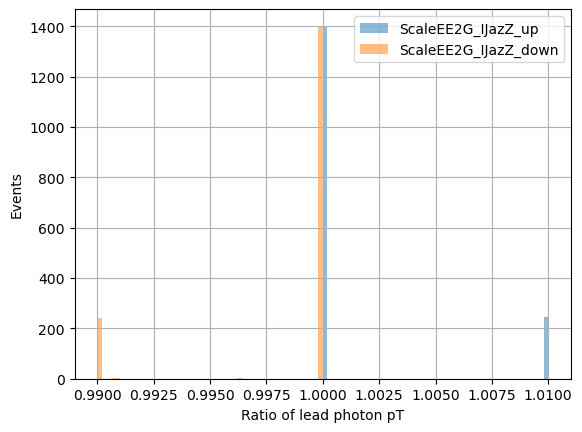

In [24]:
plt.hist(file_up_comm.pholead_pt/file_common.pholead_pt, bins=50, alpha=0.5, label='ScaleEE2G_IJazZ_up')
plt.hist(file_down_comm.pholead_pt/file_common.pholead_pt, bins=50, alpha=0.5, label='ScaleEE2G_IJazZ_down')
plt.xlabel('Ratio of lead photon pT')
plt.ylabel('Events')
plt.legend()
plt.grid()
plt.show()

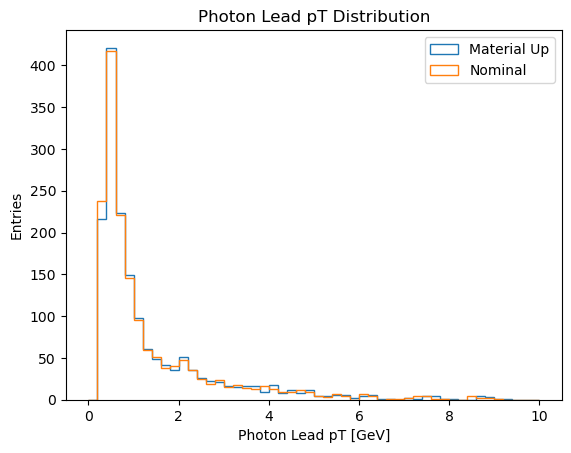

In [131]:
plt.hist(file_matup_comm.pholead_energyErr, bins=50, range=(0, 10), histtype='step', label='Material Up')
plt.hist(file_common.pholead_energyErr, bins=50, range=(0, 10), histtype='step', label='Nominal')
plt.xlabel('Photon Lead pT [GeV]')
plt.ylabel('Entries')
plt.title('Photon Lead pT Distribution')
plt.legend()
plt.show()

In [8]:
ROOT.gStyle.SetOptStat(0)

# Convert to numpy (important)
pt_nom = np.asarray(file_common.pholead_pt)
pt_up  = np.asarray(file_matup_comm.pholead_pt)

# Histogram settings
nbins = 100
xmin, xmax = 0, 200

h_nom = ROOT.TH1F("h_nom", "Photon Lead p_{T};p_{T} [GeV];Entries", nbins, xmin, xmax)
h_up  = ROOT.TH1F("h_up",  "Photon Lead p_{T};p_{T} [GeV];Entries", nbins, xmin, xmax)
h_nom.SetMinimum(0.1)
h_up.SetMinimum(0.1)

# Fill histograms
for x in pt_nom:
    h_nom.Fill(x)

for x in pt_up:
    h_up.Fill(x)

# Style
h_nom.SetLineColor(ROOT.kBlack)
h_nom.SetLineWidth(2)

h_up.SetLineColor(ROOT.kRed)
h_up.SetLineWidth(2)

# Canvas
c = ROOT.TCanvas("c", "Photon Lead pT", 800, 800)

# Pads
pad1 = ROOT.TPad("pad1", "pad1", 0, 0.30, 1, 1.00)
pad2 = ROOT.TPad("pad2", "pad2", 0, 0.00, 1, 0.30)

pad1.SetBottomMargin(0.02)
pad2.SetTopMargin(0.05)
pad2.SetBottomMargin(0.30)

pad1.Draw()
pad2.Draw()

# ---- Upper pad (main plot)
pad1.cd()
# pad1.SetLogy()

h_nom.Draw("HIST")
h_up.Draw("HIST SAME")

h_nom.GetYaxis().SetTitleOffset(1.2)
h_nom.GetXaxis().SetLabelSize(0)

# Legend
leg = ROOT.TLegend(0.60, 0.75, 0.88, 0.88)
leg.SetBorderSize(0)
leg.SetFillStyle(0)
leg.AddEntry(h_nom, "Nominal", "l")
leg.AddEntry(h_up,  "Material Up", "l")
leg.Draw()

# ---- Lower pad (ratio)
pad2.cd()


h_ratio = h_up.Clone("h_ratio")
h_ratio.Divide(h_nom)

h_ratio.SetTitle("")
h_ratio.GetYaxis().SetTitle("Up / Nominal")
h_ratio.GetYaxis().SetNdivisions(505)
h_ratio.GetYaxis().SetTitleSize(0.10)
h_ratio.GetYaxis().SetTitleOffset(0.45)
h_ratio.GetYaxis().SetLabelSize(0.08)

h_ratio.GetXaxis().SetTitle("p_{T} [GeV]")
h_ratio.GetXaxis().SetTitleSize(0.12)
h_ratio.GetXaxis().SetLabelSize(0.10)

h_ratio.SetLineColor(ROOT.kRed)
h_ratio.SetMarkerStyle(20)

h_ratio.SetMinimum(0.9)
h_ratio.SetMaximum(1.1)

h_ratio.Draw("P")

# Reference line at 1
line = ROOT.TLine(xmin, 1.0, xmax, 1.0)
line.SetLineStyle(2)
line.Draw()

c.Update()
c.Draw()


c.SaveAs("photon_lead_pt_material_up_vs_nominal.png")


Info in <TCanvas::Print>: png file photon_lead_pt_material_up_vs_nominal.png has been created


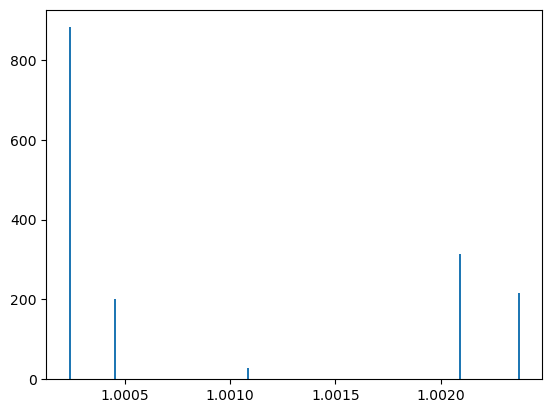

In [14]:
plt.hist(pt_up/pt_nom, bins = 200);

In [61]:
file.event_idx

<Array [13, 174, 183, 205, ..., 279765, 279814, 279846] type='3966 * int64'>

In [62]:
file_matup.event_idx

<Array [13, 174, 183, 205, ..., 279765, 279814, 279846] type='3959 * int64'>

In [1]:
import correctionlib
from correctionlib import CorrectionSet

In [2]:
json_file = "/eos/user/b/bbapi/JSON_checker/jet_jerc.json"

In [3]:
cset = CorrectionSet.from_file(json_file)

In [5]:
print(list(cset.keys()))

['Summer23BPixPrompt23_RunD_JRV1_MC_PtResolution_AK4PFPuppi', 'Summer23BPixPrompt23_RunD_JRV1_MC_ScaleFactor_AK4PFPuppi', 'Summer24Prompt24_V2_DATA_L1FastJet_AK4PFPuppi', 'Summer24Prompt24_V2_DATA_L2L3Residual_AK4PFPuppi', 'Summer24Prompt24_V2_DATA_L2Relative_AK4PFPuppi', 'Summer24Prompt24_V2_DATA_L3Absolute_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteFlavMap_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteMPFBias_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteSample_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteScale_AK4PFPuppi', 'Summer24Prompt24_V2_MC_AbsoluteStat_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupFlavor_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupIntercalibration_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupMPFInSitu_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupUncorrelated_AK4PFPuppi', 'Summer24Prompt24_V2_MC_CorrelationGroupbJES_AK4PFPuppi', 'Summer24Prompt24_V2_MC_FlavorPhotonJet_AK4PFPuppi', 'Summer24Prompt24_V2_MC_FlavorPureBottom_AK4PFPu

In [6]:
corr = cset["Summer24Prompt24_V2_MC_L1FastJet_AK4PFPuppi"]
print(corr.inputs)

[<correctionlib._core.Variable object at 0x7fdf300fab70>, <correctionlib._core.Variable object at 0x7fdf300fa130>, <correctionlib._core.Variable object at 0x7fdf300f91b0>, <correctionlib._core.Variable object at 0x7fdf300fa330>]


In [ ]:
for v in corr.inputs:
    print(f"name={v.name}, type={v.type}, desc={v.description}")

name=JetA, type=real, desc=area of the jet
name=JetEta, type=real, desc=pseudorapidity of the jet
name=JetPt, type=real, desc=pT of the jet before specific correction (for JER and uncertainties: after all corrections applied)
name=Rho, type=real, desc=energy density rho (as measure of PU)


In [20]:
jet_area = 0.4
jet_eta  = 0.4
jet_pt   = 23.0   # fully corrected pt if JES/JER
rho      = 10.0

unc = corr.evaluate(jet_area, jet_eta, jet_pt, rho)
print(unc)

1.0


In [12]:
print(corr.description)

L1FastJet for AK4PFPuppi jets, created from Summer24Prompt24_V2_MC using https://gitlab.cern.ch/cms-jetmet/jerc2json


In [13]:
print(corr.output)

In [15]:
v = corr.output
print(f"name={v.name}, type={v.type}, desc={v.description}")


name=correction, type=real, desc=


In [21]:
print(corr.name)

Summer24Prompt24_V2_MC_L1FastJet_AK4PFPuppi


In [24]:
dir(corr)

['__class__',
 '__delattr__',
 '__dict__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__getstate__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__module__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__setstate__',
 '__sizeof__',
 '__str__',
 '__subclasshook__',
 '__weakref__',
 '_base',
 '_context',
 '_name',
 'description',
 'evaluate',
 'inputs',
 'name',
 'output',
 'version']

In [ ]:
import json

ROOT.gStyle.SetOptStat(0)

# Load JSON
with open("/eos/user/b/bbapi/HiggsDNA/higgs_dna/systematics/JSONs/SF_photon_ID/2023postBPix/IDMVA0p19_2023PostBPiX.json") as f:
    data = json.load(f)

corr = data["corrections"][0]["data"]

def extract_block(block):
    eta_edges = block["edges"]
    contents = block["content"]

    result = []
    for i, eta_bin in enumerate(contents):
        pt_edges = eta_bin["edges"][0]
        values = eta_bin["content"]
        result.append((eta_edges[i], eta_edges[i+1], pt_edges, values))
    return result

nominal_blocks = extract_block(corr["default"])

# Build 2D histogram
eta_edges = nominal_blocks[0][2]  # pT edges
pt_edges = nominal_blocks[0][2]

h2 = ROOT.TH2F(
    "h2", "IDMVA SF; p_{T}; |#eta_{SC}|",
    len(pt_edges)-1, np.array(pt_edges, dtype='double'),
    2, 0, 2
)

for i, (eta_min, eta_max, pt_edges, vals_nom) in enumerate(nominal_blocks):
    for j, val in enumerate(vals_nom):
        h2.SetBinContent(j+1, i+1, val)

# c2 = ROOT.TCanvas()
c2 = ROOT.TCanvas("c2", "", 1400, 800)
c2.SetLogx()
c2.SetRightMargin(0.12)
h2.Draw("COLZ TEXT")
c2.SaveAs("idmva_sf_2D.png")

Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c2
Info in <TCanvas::Print>: png file idmva_sf_2D.png has been created


In [36]:
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPaintTextFormat("1.5f")

# Load JSON
with open("/eos/user/b/bbapi/HiggsDNA/higgs_dna/systematics/JSONs/SF_photon_ID/2023postBPix/IDMVA0p19_2023PostBPiX.json") as f:
    data = json.load(f)

corr = data["corrections"][0]["data"]

# ---------------------------
# Helper to extract blocks
# ---------------------------
def extract_block(block):
    eta_edges = block["edges"]
    contents = block["content"]

    result = []
    for i, eta_bin in enumerate(contents):
        pt_edges = eta_bin["edges"][0]
        values = eta_bin["content"]
        result.append((eta_edges[i], eta_edges[i+1], pt_edges, values))
    return result

# ---------------------------
# Extract nominal
# ---------------------------
nominal_blocks = extract_block(corr["default"])

# ---------------------------
# Correct edges
# ---------------------------
eta_edges = corr["default"]["edges"]     # correct η edges
pt_edges  = nominal_blocks[0][2]         # pT edges

# ---------------------------
# Build histogram with variable binning
# ---------------------------
h2 = ROOT.TH2F(
    "h2", "IDMVA SF; p_{T} [GeV]; |#eta_{SC}|",
    len(pt_edges)-1, np.array(pt_edges, dtype='double'),
    len(eta_edges)-1, np.array(eta_edges, dtype='double')
)

# ---------------------------
# Fill histogram
# ---------------------------
for i, (eta_min, eta_max, pt_edges, vals_nom) in enumerate(nominal_blocks):
    for j, val in enumerate(vals_nom):
        h2.SetBinContent(j+1, i+1, val)

# ---------------------------
# Optional: nicer η bin labels
# ---------------------------
for i in range(len(eta_edges)-1):
    label = f"{eta_edges[i]}-{eta_edges[i+1]}"
    h2.GetYaxis().SetBinLabel(i+1, label)

# ---------------------------
# Draw
# ---------------------------
c2 = ROOT.TCanvas("c2", "", 1400, 800)
c2.SetLogx()
c2.SetRightMargin(0.12)

h2.SetMarkerSize(1.0)   # reduce overlap
h2.Draw("COLZ TEXT")

c2.SaveAs("idmva_sf_2D.png")

Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c2
Info in <TCanvas::Print>: png file idmva_sf_2D.png has been created


In [ ]:
ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPaintTextFormat("1.5f")

# Load JSON
with open("/eos/user/b/bbapi/HiggsDNA/higgs_dna/systematics/JSONs/SF_photon_ID/2023postBPix/IDMVA0p19_2023PostBPiX.json") as f:
    data = json.load(f)

corr = data["corrections"][0]["data"]

# ---------------------------
# Helper
# ---------------------------
def extract_block(block):
    eta_edges = block["edges"]
    contents = block["content"]

    result = []
    for i, eta_bin in enumerate(contents):
        pt_edges = eta_bin["edges"][0]
        values = eta_bin["content"]
        result.append((eta_edges[i], eta_edges[i+1], pt_edges, values))
    return result

# ===========================
# CHOOSE WHAT TO PLOT
# ===========================

# --- NOMINAL ---
# block = corr["default"]
# title = "IDMVA SF"

# --- UNCERTAINTY ---
block = next(x["value"] for x in corr["content"] if x["key"] == "uncertainty")
title = "IDMVA SF Uncertainty"

# ---------------------------
# Extract
# ---------------------------
blocks = extract_block(block)

eta_edges = block["edges"]
pt_edges  = blocks[0][2]

# ---------------------------
# Histogram
# ---------------------------
h2 = ROOT.TH2F(
    "h2", f"{title}; p_{{T}} [GeV]; |#eta_{{SC}}|",
    len(pt_edges)-1, np.array(pt_edges, dtype='double'),
    len(eta_edges)-1, np.array(eta_edges, dtype='double')
)

# ---------------------------
# Fill
# ---------------------------
for i, (eta_min, eta_max, pt_edges, vals) in enumerate(blocks):
    for j, val in enumerate(vals):
        h2.SetBinContent(j+1, i+1, val)

# Optional: nicer η labels
for i in range(len(eta_edges)-1):
    h2.GetYaxis().SetBinLabel(i+1, f"{eta_edges[i]}-{eta_edges[i+1]}")

# ---------------------------
# Draw (same style)
# ---------------------------
c = ROOT.TCanvas("c", "", 1400, 800)
c.SetLogx()
c.SetRightMargin(0.12)

h2.SetMarkerSize(1.0)
h2.Draw("COLZ TEXT")

c.SaveAs("idmva_sf_uncertainty.png")

Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file idmva_sf_uncertainty.png has been created


In [28]:
import json
import numpy as np

ROOT.gStyle.SetOptStat(0)

Plot_dir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/TriggerSF/"

# -------------------------------
# Load JSON
# -------------------------------
with open("/eos/user/b/bbapi/HiggsDNA/higgs_dna/systematics/JSONs/TriggerSF/2024/TriggerSF_lead_2024.json") as f:
    data = json.load(f)

corr = data["corrections"][0]["data"]

# -------------------------------
# Extract binning
# -------------------------------
edges_eta = corr["default"]["edges"][0]
edges_r9  = corr["default"]["edges"][1]
edges_pt  = corr["default"]["edges"][2]

edges_pt[-1] = 200.0  # cap last bin at 200 GeV

n_eta = len(edges_eta) - 1
n_r9  = len(edges_r9) - 1
n_pt  = len(edges_pt) - 1

# -------------------------------
# Get content
# -------------------------------
def get_content(systematic):
    if systematic == "default":
        return corr["default"]["content"]
    else:
        for c in corr["content"]:
            if c["key"] == systematic:
                return c["value"]["content"]

# -------------------------------
# Build TH2
# -------------------------------
def make_TH2(content, i_r9, name):
    h = ROOT.TH2F(
        name, "",
        n_eta, np.array(edges_eta, dtype='float64'),
        n_pt,  np.array(edges_pt, dtype='float64')
    )

    h.GetXaxis().SetRangeUser(0.1, h.GetXaxis().GetXmax())
    h.GetYaxis().SetRangeUser(0.1, 200)

    for i_eta in range(n_eta):
        for i_pt in range(n_pt):

            idx = i_eta * (n_r9 * n_pt) + i_r9 * n_pt + i_pt
            value = content[idx]

            h.SetBinContent(i_eta+1, i_pt+1, value)

    return h

# -------------------------------
# Plot + Save (one canvas per R9)
# -------------------------------
systematics = ["default", "up", "down"]

for syst in systematics:

    content = get_content(syst)

    for i_r9 in range(n_r9):

        c = ROOT.TCanvas(f"c_{syst}_r9_{i_r9}", "", 800, 700)
        c.SetRightMargin(0.15)

        label = f"{edges_r9[i_r9]} < R9 < {edges_r9[i_r9+1]}"
        h = make_TH2(content, i_r9, f"{syst}_r9_{i_r9}")

        h.SetTitle(f"{syst} | {label};|#eta|;p_{{T}} (GeV)")
        h.GetZaxis().SetTitle("TriggerSF")
        h.GetZaxis().SetTitleOffset(1.4)

        h.Draw("COLZ")

        # remove logX (eta should be linear)
        ROOT.gPad.SetLogx()

        # Optional: improve visibility
        # ROOT.gPad.SetLogz()
        # h.SetMinimum(1e-6)

        c.Update()

        # -------------------------------
        # Save each R9 separately
        # -------------------------------
        c.SaveAs(Plot_dir+f"{syst}_r9_{i_r9}.png")
        c.SaveAs(Plot_dir+f"{syst}_r9_{i_r9}.pdf")

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/TriggerSF/default_r9_0.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/TriggerSF/default_r9_0.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/TriggerSF/default_r9_1.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/TriggerSF/default_r9_1.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/TriggerSF/default_r9_2.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/TriggerSF/default_r9_2.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/TriggerSF/default_r9_3.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Trig

In [31]:
import json
import numpy as np
import ROOT

ROOT.gStyle.SetOptStat(0)

Plot_dir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/"

# -------------------------------
# Load JSON
# -------------------------------
with open("/eos/user/b/bbapi/HiggsDNA/higgs_dna/systematics/JSONs/Preselection/2023postBPix/Preselection_2023PostBPiX.json") as f:
    data = json.load(f)

corr = data["corrections"][0]["data"]["default"]

edges_eta = corr["edges"]
eta_blocks = corr["content"]

# -------------------------------
# Loop over eta and R9
# -------------------------------
# for i_eta, eta_block in enumerate(eta_blocks):

#     edges_r9 = eta_block["edges"]
#     r9_blocks = eta_block["content"]

#     for i_r9, r9_block in enumerate(r9_blocks):

#         pt_edges = r9_block["edges"][0]
#         values   = r9_block["content"]

#         n_pt = len(values)

#         # -------------------------------
#         # Build histogram
#         # -------------------------------
#         h = ROOT.TH1F(
#             f"h_eta{i_eta}_r9{i_r9}",
#             "",
#             n_pt,
#             np.array(pt_edges, dtype='float64')
#         )

#         for i in range(n_pt):
#             h.SetBinContent(i+1, values[i])

        # # -------------------------------
        # # Plot
        # # -------------------------------
        # c = ROOT.TCanvas(f"c_eta{i_eta}_r9{i_r9}", "", 800, 600)

        # label = f"{edges_eta[i_eta]} < |eta| < {edges_eta[i_eta+1]}, "
        # label += f"{edges_r9[i_r9]} < R9 < {edges_r9[i_r9+1]}"

        # h.SetTitle(f"Preselection SF; p_{{T}} (GeV); SF")
        # h.SetMarkerStyle(20)
        # h.SetLineWidth(2)

        # h.Draw("E1")

        # # Optional styling
        # h.SetMinimum(0.98)
        # h.SetMaximum(1.05)

        # ROOT.gPad.SetLogx()

        # # Add label
        # txt = ROOT.TLatex()
        # txt.SetNDC()
        # txt.SetTextSize(0.035)
        # txt.DrawLatex(0.15, 0.85, label)

        # c.SaveAs(Plot_dir+f"SF_eta{i_eta}_r9{i_r9}.png")


# -------------------------------
# Loop over eta (1 canvas per eta)
# -------------------------------
for i_eta, eta_block in enumerate(eta_blocks):

    c = ROOT.TCanvas(f"c_eta{i_eta}", "", 800, 600)

    edges_r9 = eta_block["edges"]
    r9_blocks = eta_block["content"]

    legend = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)

    colors = [ROOT.kRed, ROOT.kBlue]

    hists = []

    for i_r9, r9_block in enumerate(r9_blocks):

        pt_edges = r9_block["edges"][0]
        values   = r9_block["content"]

        n_pt = len(values)

        h = ROOT.TH1F(
            f"h_eta{i_eta}_r9{i_r9}",
            "",
            n_pt,
            np.array(pt_edges, dtype='float64')
        )

        for i in range(n_pt):
            h.SetBinContent(i+1, values[i])

        # Styling
        h.SetLineColor(colors[i_r9])
        h.SetMarkerColor(colors[i_r9])
        h.SetMarkerStyle(20)
        h.SetLineWidth(2)

        label_r9 = f"{edges_r9[i_r9]} < R9 < {edges_r9[i_r9+1]}"
        legend.AddEntry(h, label_r9, "lp")

        hists.append(h)

    # -------------------------------
    # Draw
    # -------------------------------
    hists[0].SetTitle(f"{edges_eta[i_eta]} < |#eta| < {edges_eta[i_eta+1]};p_{{T}} (GeV);SF")
    hists[0].SetMinimum(0.98)
    hists[0].SetMaximum(1.05)

    hists[0].Draw("P")
    hists[1].Draw("P SAME")

    ROOT.gPad.SetLogx()

    legend.Draw()

    c.SaveAs(Plot_dir+f"SF_eta{i_eta}_combined.png")


Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta0_combined.png has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta1_combined.png has been created


In [36]:
import json
import numpy as np

ROOT.gStyle.SetOptStat(0)

Plot_dir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/"

# -------------------------------
# Load JSON
# -------------------------------
with open("/eos/user/b/bbapi/HiggsDNA/higgs_dna/systematics/JSONs/Preselection/2023postBPix/Preselection_2023PostBPiX.json") as f:
    data = json.load(f)

corr_full = data["corrections"][0]["data"]

# Nominal
corr_nom = corr_full["default"]

# Uncertainty
for c in corr_full["content"]:
    if c["key"] == "uncertainty":
        corr_unc = c["value"]

edges_eta = corr_nom["edges"]

# -------------------------------
# Loop over eta (1 canvas per eta)
# -------------------------------
for i_eta, (eta_nom, eta_unc) in enumerate(zip(corr_nom["content"], corr_unc["content"])):

    c = ROOT.TCanvas(f"c_eta{i_eta}", "", 800, 600)

    edges_r9 = eta_nom["edges"]

    legend = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)
    legend.SetBorderSize(0)

    colors = [ROOT.kRed, ROOT.kBlue]

    hists = []

    for i_r9, (r9_nom, r9_unc) in enumerate(zip(eta_nom["content"], eta_unc["content"])):

        pt_edges = r9_nom["edges"][0]
        values   = r9_nom["content"]
        errors   = r9_unc["content"]

        n_pt = len(values)

        h = ROOT.TH1F(
            f"h_eta{i_eta}_r9{i_r9}",
            "",
            n_pt,
            np.array(pt_edges, dtype='float64')
        )

        # Fill content + uncertainty
        for i in range(n_pt):
            h.SetBinContent(i+1, values[i])
            h.SetBinError(i+1, errors[i])

        # Style
        h.SetLineColor(colors[i_r9])
        h.SetMarkerColor(colors[i_r9])
        h.SetFillColorAlpha(colors[i_r9], 0.3)
        h.SetMarkerStyle(20 + i_r9)
        h.SetLineWidth(2)

        label_r9 = f"{edges_r9[i_r9]} < R9 < {edges_r9[i_r9+1]}"
        legend.AddEntry(h, label_r9, "lp")

        hists.append(h)

    # -------------------------------
    # Draw
    # -------------------------------
    title = f"{edges_eta[i_eta]} < |#eta| < {edges_eta[i_eta+1]}"
    hists[0].SetTitle(f"{title};p_{{T}} (GeV);SF")

    hists[0].SetMinimum(0.98)
    hists[0].SetMaximum(1.05)
    hists[0].GetXaxis().SetLimits(1, 1500)
    hists[0].GetXaxis().SetMoreLogLabels()

    # Draw bands + lines
    hists[0].Draw("E3")
    hists[0].Draw("PL SAME")

    hists[1].Draw("E3 SAME")
    hists[1].Draw("PL SAME")

    ROOT.gPad.SetLogx()
    ROOT.gPad.SetGrid()

    legend.Draw()

    # Label
    txt = ROOT.TLatex()
    txt.SetNDC()
    txt.SetTextSize(0.04)
    txt.DrawLatex(0.15, 0.92, "Preselection SF")

    c.Update()

    c.SaveAs(Plot_dir + f"SF_eta{i_eta}_combined.png")
    c.SaveAs(Plot_dir + f"SF_eta{i_eta}_combined.pdf")

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta0_combined.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta0_combined.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta1_combined.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta1_combined.pdf has been created


In [5]:
import json
import numpy as np

ROOT.gStyle.SetOptStat(0)

Plot_dir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/Single_ele_TriggerSF/"

# -------------------------------
# Load JSON
# -------------------------------
with open("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/electronHlt.json") as f:
    data = json.load(f)

# corr_full = data["corrections"][0]["data"]


In [14]:
data_corr = data["corrections"][0]["data"]['content']

In [80]:
dict = data_corr[0]['value']['content'][0]['value']['content'][4]['value']

ROOT.gStyle.SetOptStat(0)
ROOT.gStyle.SetPaintTextFormat(".3f")

# -------------------------------
# Input (paste your dict here)
# -------------------------------
data = dict  # replace this

edges_eta = data["edges"][0]
edges_pt  = data["edges"][1]
content   = data["content"]

# -------------------------------
# Fix infinities for ROOT
# -------------------------------
def fix_edges(edges, low=-3.0, high=3.0):
    fixed = []
    for x in edges:
        if x == float("-inf"):
            fixed.append(low)
        elif x == float("inf"):
            fixed.append(high)
        else:
            fixed.append(x)
    return fixed

edges_eta = fix_edges(edges_eta, -2.5, 2.5)
edges_pt  = fix_edges(edges_pt, 25, 200)

n_eta = len(edges_eta) - 1
n_pt  = len(edges_pt) - 1

# -------------------------------
# Create TH2
# -------------------------------
h = ROOT.TH2F(
    "h", "Single Electron SF;#eta;p_{T} (GeV)",
    n_eta, np.array(edges_eta, dtype='float64'),
    n_pt,  np.array(edges_pt, dtype='float64')
)

# -------------------------------
# Fill histogram
# -------------------------------
for i_eta in range(n_eta):
    for i_pt in range(n_pt):

        idx = i_eta * n_pt + i_pt
        h.SetBinContent(i_eta+1, i_pt+1, content[idx])

# -------------------------------
# Plot
# -------------------------------
c = ROOT.TCanvas("c", "SF map", 800, 700)
c.SetRightMargin(0.15)
c.SetLeftMargin(0.13)

h.GetZaxis().SetTitle("Trigger Scale Factor")
h.Draw("COLZ TEXT")
h.SetMarkerSize(0.8)
h.GetYaxis().SetMoreLogLabels()
h.GetYaxis().SetTitleOffset(1.8)
c.SetLogy()

c.SaveAs(Plot_dir+"single_ele_SF.png")
c.SaveAs(Plot_dir+"single_ele_SF.pdf")

Warning in <TROOT::Append>: Replacing existing TH1: h (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Single_ele_TriggerSF/single_ele_SF.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Single_ele_TriggerSF/single_ele_SF.pdf has been created


In [81]:
dict

{'nodetype': 'multibinning',
 'inputs': ['eta', 'pt'],
 'edges': [[-inf,
   -2.0,
   -1.566,
   -1.444,
   -0.8,
   0.0,
   0.8,
   1.444,
   1.566,
   2.0,
   inf],
  [25.0, 30.0, 32.0, 35.0, 40.0, 45.0, 50.0, 75.0, 100.0, 200.0, inf]],
 'content': [1.1695677042007446,
  0.8197245001792908,
  0.8738634586334229,
  0.9306570887565613,
  0.9745694398880005,
  0.9670416116714478,
  0.9748414754867554,
  0.9937071800231934,
  0.984743058681488,
  0.9718955159187317,
  0.4976555109024048,
  0.6609823107719421,
  0.8383285999298096,
  0.8993330001831055,
  0.9454768300056458,
  0.9495403170585632,
  0.9799668192863464,
  0.9805892109870911,
  0.9951435923576355,
  1.020720362663269,
  0.35969868302345276,
  0.7322761416435242,
  0.6964744925498962,
  0.924328625202179,
  0.9632092714309692,
  1.017268180847168,
  0.9726819396018982,
  1.0577422380447388,
  1.0435688495635986,
  0.7471959590911865,
  0.39660266041755676,
  0.5803428888320923,
  0.8527023196220398,
  0.9612483382225037,
  0.9

In [39]:
import json
import numpy as np
import ROOT

ROOT.gStyle.SetOptStat(0)

# ---------------------------
# Load JSON
# ---------------------------
with open("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/pileup_2024.json") as f:
    data = json.load(f)

# ---------------------------
# Navigate to correction
# ---------------------------
corr = data["corrections"][0]["data"]

# Usually pileup has category → choose nominal/default
if corr["nodetype"] == "category":
    # take default or "nominal"
    block = corr.get("default", None)

    if block is None:
        block = next(x["value"] for x in corr["content"] if x["key"] == "nominal")
else:
    block = corr

# ---------------------------
# Extract edges & values
# ---------------------------
edges = block["edges"]
values = block["content"]

# ---------------------------
# Create histogram
# ---------------------------
h1 = ROOT.TH1F(
    "h1", "Pileup SF; nPU; Weight",
    len(edges)-1, np.array(edges, dtype='double')
)

# ---------------------------
# Fill histogram
# ---------------------------
for i, val in enumerate(values):
    h1.SetBinContent(i+1, val)

# ---------------------------
# Style
# ---------------------------
h1.SetLineWidth(2)
h1.SetLineColor(ROOT.kBlue)

# ---------------------------
# Canvas
# ---------------------------
c = ROOT.TCanvas("c", "Pileup SF", 1000, 700)
c.SetRightMargin(0.05)

# Log scale (important for PU tails)
c.SetLogy()

h1.Draw("HIST")

c.SaveAs("pileup_sf.png")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file pileup_sf.png has been created


In [ ]:
import json
import numpy as np

ROOT.gStyle.SetOptStat(0)

Plot_dir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/"

# -------------------------------
# Load JSON
# -------------------------------
with open("/eos/user/b/bbapi/HiggsDNA/higgs_dna/systematics/JSONs/Preselection/2023postBPix/Preselection_2023PostBPiX.json") as f:
    data = json.load(f)

corr_full = data["corrections"][0]["data"]

# Nominal
corr_nom = corr_full["default"]

# Uncertainty
for c in corr_full["content"]:
    if c["key"] == "uncertainty":
        corr_unc = c["value"]

edges_eta = corr_nom["edges"]

# -------------------------------
# Loop over eta (1 canvas per eta)
# -------------------------------
for i_eta, (eta_nom, eta_unc) in enumerate(zip(corr_nom["content"], corr_unc["content"])):

    c = ROOT.TCanvas(f"c_eta{i_eta}", "", 800, 600)

    edges_r9 = eta_nom["edges"]

    legend = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)
    legend.SetBorderSize(0)

    colors = [ROOT.kRed, ROOT.kBlue]

    hists = []

    for i_r9, (r9_nom, r9_unc) in enumerate(zip(eta_nom["content"], eta_unc["content"])):

        pt_edges = r9_nom["edges"][0]
        values   = r9_nom["content"]
        errors   = r9_unc["content"]

        n_pt = len(values)

        h = ROOT.TH1F(
            f"h_eta{i_eta}_r9{i_r9}",
            "",
            n_pt,
            np.array(pt_edges, dtype='float64')
        )

        # Fill content + uncertainty
        for i in range(n_pt):
            h.SetBinContent(i+1, values[i])
            h.SetBinError(i+1, errors[i])

        # Style
        h.SetLineColor(colors[i_r9])
        h.SetMarkerColor(colors[i_r9])
        h.SetFillColorAlpha(colors[i_r9], 0.3)
        h.SetMarkerStyle(20 + i_r9)
        h.SetLineWidth(2)

        label_r9 = f"{edges_r9[i_r9]} < R9 < {edges_r9[i_r9+1]}"
        legend.AddEntry(h, label_r9, "lp")

        hists.append(h)

    # -------------------------------
    # Draw
    # -------------------------------
    title = f"{edges_eta[i_eta]} < |#eta| < {edges_eta[i_eta+1]}"
    hists[0].SetTitle(f"{title};p_{{T}} (GeV);SF")

    hists[0].SetMinimum(0.98)
    hists[0].SetMaximum(1.05)
    hists[0].GetXaxis().SetLimits(1, 1500)
    hists[0].GetXaxis().SetMoreLogLabels()

    # Draw bands + lines
    hists[0].Draw("E3")
    hists[0].Draw("PL SAME")

    hists[1].Draw("E3 SAME")
    hists[1].Draw("PL SAME")

    ROOT.gPad.SetLogx()
    ROOT.gPad.SetGrid()

    legend.Draw()

    # Label
    txt = ROOT.TLatex()
    txt.SetNDC()
    txt.SetTextSize(0.04)
    txt.DrawLatex(0.15, 0.92, "Preselection SF")

    c.Update()

    c.SaveAs(Plot_dir + f"SF_eta{i_eta}_combined.png")
    c.SaveAs(Plot_dir + f"SF_eta{i_eta}_combined.pdf")

Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta0_combined.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta0_combined.pdf has been created
Info in <TCanvas::Print>: png file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta1_combined.png has been created
Info in <TCanvas::Print>: pdf file /eos/user/b/bbapi/www/Systematics_study/JSON_plots/Presel_SF/SF_eta1_combined.pdf has been created


In [41]:
ROOT.gStyle.SetOptStat(0)

# ---------------------------
# Load JSON
# ---------------------------
with open("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/pileup_2024.json") as f:
    data = json.load(f)

corr = data["corrections"][0]["data"]

# ---------------------------
# Extract blocks
# ---------------------------
blocks = {}

if corr["nodetype"] == "category":
    # default → nominal
    if "default" in corr:
        blocks["nominal"] = corr["default"]

    for item in corr["content"]:
        blocks[item["key"]] = item["value"]
else:
    blocks["nominal"] = corr

# ---------------------------
# Colors
# ---------------------------
colors = {
    "nominal": ROOT.kBlack,
    "up": ROOT.kRed,
    "down": ROOT.kBlue
}

# ---------------------------
# Canvas
# ---------------------------
c = ROOT.TCanvas("c", "Pileup SF Variations", 1000, 700)
c.SetLogy()
c.SetRightMargin(0.05)

legend = ROOT.TLegend(0.2, 0.7, 0.38, 0.88)
legend.SetBorderSize(0)
legend.SetFillColor(0)
legend.SetFillStyle(0)

first = True
hists = []

# ---------------------------
# Loop over variations
# ---------------------------
for name, block in blocks.items():

    edges = block["edges"]
    values = block["content"]

    h = ROOT.TH1F(
        f"h_{name}", "Pileup SF; nPU; Weight",
        len(edges)-1, np.array(edges, dtype='double')
    )

    for i, val in enumerate(values):
        h.SetBinContent(i+1, val)

    h.SetLineColor(colors.get(name, ROOT.kGreen+2))
    h.SetLineWidth(2)

    draw_opt = "HIST" if first else "HIST SAME"
    h.Draw(draw_opt)

    legend.AddEntry(h, name, "l")

    first = False
    hists.append(h)

legend.Draw()
c.SaveAs("pileup_sf_nom_up_down.png")

Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file pileup_sf_nom_up_down.png has been created


# Pileup calculations

In [ ]:
from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
file = '/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/skimmed_TTG1Jets/TTG1Jets_preselected.root'
factory = NanoEventsFactory.from_root(
    f"{file}:Events",
    schemaclass=NanoAODSchema,
)
events = factory.events()

In [14]:
file_raw = 'root://xrootd-cms.infn.it///store/mc/RunIII2024Summer24NanoAODv15/TTG-1Jets_TuneCP5_13p6TeV_amcatnloFXFXold-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v2/120000/31088ed2-e940-45a0-85af-a299e67d1a57.root'
factory = NanoEventsFactory.from_root(
    f"{file_raw}:Events",
    schemaclass=NanoAODSchema,
)
events_raw = factory.events()

In [4]:
events.fields

['DeepMETResponseTune',
 'TrackGenJetAK4',
 'SoftActivityJetHT10',
 'Tau',
 'SV',
 'boostedTau',
 'Electron',
 'SoftActivityJetNjets10',
 'Photon',
 'DST',
 'Muon',
 'LowPtElectron',
 'TrkMET',
 'LHEPdfWeight',
 'event',
 'PVBS',
 'SubGenJetAK8',
 'Generator',
 'genTtbarId',
 'SubJet',
 'HLT',
 'L1',
 'bunchCrossing',
 'OtherPV',
 'genWeight',
 'GenJetAK8',
 'SoftActivityJetHT2',
 'RawPFMET',
 'CaloMET',
 'LHEScaleWeight',
 'SoftActivityJetHT5',
 'GenPart',
 'PSWeight',
 'LHEWeight',
 'orbitNumber',
 'GenDressedLepton',
 'FsrPhoton',
 'GenVtx',
 'FatJetPFCand',
 'LHE',
 'run',
 'SoftActivityJetHT',
 'FiducialMET',
 'HLTriggerFirstPath',
 'CorrT1METJet',
 'Pileup',
 'SoftActivityJetNjets5',
 'HLTriggerFinalPath',
 'BeamSpot',
 'MC',
 'TauProd',
 'TrigObj',
 'LHEReweightingWeight',
 'RawPuppiMET',
 'DeepMETResolutionTune',
 'GenJet',
 'PuppiMET',
 'PV',
 'Flag',
 'PFMET',
 'SoftActivityJetNjets2',
 'L1Reco',
 'FatJet',
 'Dataset',
 'GenMET',
 'luminosityBlock',
 'GenProton',
 'PFCand',
 

In [5]:
events.Pileup.fields

['nPU',
 'sumEOOT',
 'sumLOOT',
 'nTrueInt',
 'pudensity',
 'gpudensity',
 'pthatmax']

In [10]:
events.Pileup.nTrueInt*1

<Array [40, 52.2, 56.3, ..., 39.6, 40.9, 40.2] type='64566 * float32[parame...'>

In [15]:
# Create histogram
h = ROOT.TH1F("h_pu", "Pileup distribution_raw; nTrueInt; Events", 100, 0, 100)

for v in events_raw.Pileup.nTrueInt:
    h.Fill(v)

# Draw
c = ROOT.TCanvas("c", "c", 800, 600)
h.Draw("hist")

# Save (optional)
c.SaveAs("pu_distribution_raw.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_pu (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file pu_distribution_raw.png has been created


In [13]:
# Create histogram
h = ROOT.TH1F("h_pu", "Pileup distribution; nTrueInt; Events", 100, 0, 100)

for v in events.Pileup.nTrueInt:
    h.Fill(v)

# Draw
c = ROOT.TCanvas("c", "c", 800, 600)
h.Draw("hist")

# Save (optional)
c.SaveAs("pu_distribution.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_pu (Potential memory leak).
Info in <TCanvas::Print>: png file pu_distribution.png has been created


In [16]:
def draw_side_statboxes(canvas, hists,
                        x1=0.80, x2=0.98,
                        y_top=0.90,
                        box_height=0.18,
                        gap=0.02):
    """
    Draw stacked statboxes on the right side of a canvas.

    Parameters
    ----------
    canvas : ROOT.TCanvas
    hists  : list of ROOT.TH1
    x1,x2  : horizontal NDC range
    y_top  : top starting NDC position
    box_height : height of each box
    gap    : vertical gap between boxes
    """

    # Temporary canvas to force stat creation
    tmp = ROOT.TCanvas("tmp_stats", "", 1, 1)

    orig_stats = {}

    for h in hists:
        h.Draw("hist")
        tmp.Update()

        st = h.GetListOfFunctions().FindObject("stats")
        if not st:
            raise RuntimeError(f"Stats not created for {h.GetName()}")

        orig_stats[h] = st.Clone(f"stats_clone_{h.GetName()}")

    tmp.Close()

    # Disable automatic stat boxes
    ROOT.gStyle.SetOptStat(0)

    canvas.cd()
    canvas.SetRightMargin(0.2)

    # Draw stacked statboxes
    for i, (hst, st) in enumerate(orig_stats.items()):

        st.SetParent(canvas)

        y2 = y_top - i * (box_height + gap)
        y1 = y2 - box_height

        st.SetX1NDC(x1)
        st.SetX2NDC(x2)
        st.SetY1NDC(y1)
        st.SetY2NDC(y2)

        st.SetTextColor(hst.GetLineColor())
        st.SetTextFont(62)   # avoid TTF bug
        st.SetFillStyle(0)
        st.SetBorderSize(1)

        st.Draw()

    canvas.Modified()
    canvas.Update()


def CMS_label(pad,
              lumi="109 fb^{-1}",
              year="2024",
              energy="13.6 TeV",
              status="Simulation Preliminary",
              x=0.12,
              y=0.92):

    pad.cd()

    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextAngle(0)
    latex.SetTextColor(ROOT.kBlack)

    # ---- CMS (bold) ----
    latex.SetTextFont(61)
    latex.SetTextSize(0.06)
    latex.DrawLatex(x, y, "CMS")

    # ---- Status (italic) ----
    if status != "":
        latex.SetTextFont(52)
        latex.SetTextSize(0.045)
        latex.DrawLatex(x + 0.11, y, status)

    # ---- Lumi text (right aligned) ----
    latex.SetTextFont(42)
    latex.SetTextSize(0.045)
    latex.SetTextAlign(31)
    lumi_text = f"({year}_{lumi})"
    latex.DrawLatex(0.88, y, lumi_text)

In [28]:
ROOT.gStyle.SetOptStat(111111)

# from coffea.nanoevents import NanoEventsFactory, NanoAODSchema
import json
import uproot

# ---------------------------
# Load JSON
# ---------------------------
with open("/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/pileup_2024.json") as f:
    data = json.load(f)

# ---------------------------
# Navigate to correction
# ---------------------------
corr = data["corrections"][0]["data"]

# Usually pileup has category → choose nominal/default
if corr["nodetype"] == "category":
    # take default or "nominal"
    block = corr.get("default", None)

    if block is None:
        block = next(x["value"] for x in corr["content"] if x["key"] == "nominal")
else:
    block = corr

# ---------------------------
# Extract edges & values
# ---------------------------
edges = block["edges"]
values = block["content"]

# ---------------------------
# Create histogram
# ---------------------------
h1 = ROOT.TH1F(
    "h1", "Pileup SF; nPU; Weight",
    len(edges)-1, np.array(edges, dtype='double')
)

# ---------------------------
# Fill histogram
# ---------------------------
for i, val in enumerate(values):
    h1.SetBinContent(i+1, val)

# ---------------------------
# Style
# ---------------------------
h1.SetLineWidth(2)
h1.SetLineColor(ROOT.kBlue)

h1.SetMaximum(100)
h1.SetMinimum(0.1)

data_pu_file = "/eos/user/b/bbapi/CMSSW_14_0_15/src/pileup_histos/pileup_2024_Golden.root"


mass = "TTG1Jets"


file_raw = 'root://xrootd-cms.infn.it///store/mc/RunIII2024Summer24NanoAODv15/TTG-1Jets_TuneCP5_13p6TeV_amcatnloFXFXold-pythia8/NANOAODSIM/150X_mcRun3_2024_realistic_v2-v2/120000/31088ed2-e940-45a0-85af-a299e67d1a57.root'
factory = NanoEventsFactory.from_root(
    f"{file_raw}:Events",
    schemaclass=NanoAODSchema,
)
Events = factory.events()

Era = "2024"


with uproot.open(data_pu_file) as f:
    data_vals, bin_edges = f["eraI/pileup"].to_numpy()
data_pdf = data_vals / np.sum(data_vals)


mc_nTrueInt = ak.to_numpy(Events.Pileup.nTrueInt)

mc_vals, _ = np.histogram(mc_nTrueInt, bins=bin_edges)
mc_pdf = mc_vals / np.sum(mc_vals)

eps = 1e-8
pu_weights_per_bin = np.where(mc_pdf > eps, data_pdf / mc_pdf, 0.0)

h_weights = ROOT.TH1F(
    f"h_weights_{mass}",
    f";PU;Weight",
    len(bin_edges)-1, bin_edges
)

h_weights.SetMaximum(100)
h_weights.SetMinimum(0.1)

for i in range(len(mc_pdf)):
    h_weights.SetBinContent(i+1, pu_weights_per_bin[i])

h_weights.SetLineColor(ROOT.kBlack)

c = ROOT.TCanvas("c", "PU comparison", 1000, 700)
c.SetLogy()

h_weights.SetLineColor(ROOT.kRed)
h_weights.SetLineWidth(2)

h1.SetLineColor(ROOT.kBlue)
h1.SetLineWidth(2)

h_weights.Draw("HIST")
h1.Draw("HIST SAME")

# Legend
leg = ROOT.TLegend(0.25, 0.75, 0.48, 0.88)
leg.AddEntry(h_weights, "Manually calculated", "l")
leg.AddEntry(h1, "From HiggsDNA JSON", "l")
leg.Draw()

CMS_label(c)

c.Update()
draw_side_statboxes(c, [h1, h_weights])
c.Update()

# c.Update()

c.SaveAs("/eos/user/b/bbapi/www/PileUp/Pileup_reweighting/2024/pu_overlay_eraI.png")


/tmp/bbapi/ipykernel_1932139/4230000822.py:84: RuntimeWarning: divide by zero encountered in divide
  pu_weights_per_bin = np.where(mc_pdf > eps, data_pdf / mc_pdf, 0.0)
Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_weights_TTG1Jets (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSiz

In [41]:
import os

ROOT.TH1.SetDefaultSumw2(True)

year = "2024"
out_dir_base = "/eos/user/b/bbapi/www/PileUp/Pileup_reweighting"
out_dir_year = os.path.join(out_dir_base, year)
with uproot.open(data_pu_file) as f:
    data_vals, bin_edges = f["era2024/pileup"].to_numpy()
    data_pdf = data_vals / np.sum(data_vals)

# fout.mkdir(year)
# fout.cd(year)

# M_MC = Events_year[ak.to_numpy(Events_year["dataset"]) == mass]
# mc_nTrueInt = ak.to_numpy(ak.flatten(Events.Pileup.nTrueInt))
mc_nTrueInt = ak.to_numpy(Events.Pileup.nTrueInt)

mc_vals, _ = np.histogram(mc_nTrueInt, bins=bin_edges)
mc_pdf = mc_vals / np.sum(mc_vals)

eps = 1e-8
pu_weights_per_bin = np.where(mc_pdf > eps, data_pdf / mc_pdf, 0.0)

bin_idx = np.digitize(mc_nTrueInt, bin_edges) - 1
bin_idx = np.clip(bin_idx, 0, len(pu_weights_per_bin) - 1)
pu_weight = pu_weights_per_bin[bin_idx]
mc_vals_rw, _ = np.histogram(mc_nTrueInt, bins=bin_edges, weights=pu_weight)
mc_pdf_rw = mc_vals_rw / np.sum(mc_vals_rw)

ratio_rw = np.where(data_pdf > eps, mc_pdf_rw / data_pdf, 0)

# h_mc = ROOT.TH1F(f"h_mc_{mass}", "MC before reweighting;PU;Normalized events", len(bin_edges)-1, bin_edges)
# h_data = ROOT.TH1F(f"h_data_{mass}", "Data;PU;Normalized events", len(bin_edges)-1, bin_edges)
# h_mc_rw = ROOT.TH1F(f"h_mc_rw_{mass}", "MC after reweighting;PU;Normalized events", len(bin_edges)-1, bin_edges)
# h_weights = ROOT.TH1F(f"h_weights_{mass}", "PU weights;PU;Weight", len(bin_edges)-1, bin_edges)
# h_ratio = ROOT.TH1F(f"h_ratio_{mass}", "Ratio MC_rw/Data;PU;Ratio", len(bin_edges)-1, bin_edges)

ROOT.gStyle.SetOptStat(1111111)

h_mc = ROOT.TH1F(
    f"h_mc_{mass}",
    f";PU;Normalized events",
    len(bin_edges)-1, bin_edges
)
h_data = ROOT.TH1F(
    f"h_data_{mass}",
    f";PU;Normalized events",
    len(bin_edges)-1, bin_edges
)
h_mc_rw = ROOT.TH1F(
    f"h_mc_rw_{mass}",
    f";PU;Normalized events",
    len(bin_edges)-1, bin_edges
)
h_weights = ROOT.TH1F(
    f"h_weights_{mass}",
    f";PU;Weight",
    len(bin_edges)-1, bin_edges
)
h_ratio = ROOT.TH1F(
    f"h_ratio_{mass}",
    f";PU;Ratio(MC_rw/Data)",
    len(bin_edges)-1, bin_edges
)



for i in range(len(mc_pdf)):
    h_mc.SetBinContent(i+1, mc_pdf[i])
    h_data.SetBinContent(i+1, data_pdf[i])
    h_mc_rw.SetBinContent(i+1, mc_pdf_rw[i])
    h_weights.SetBinContent(i+1, pu_weights_per_bin[i])
    h_ratio.SetBinContent(i+1, ratio_rw[i])

h_mc.SetLineColor(ROOT.kRed)
h_mc.SetLineWidth(2)
h_data.SetMarkerStyle(20)
h_data.SetMarkerColor(ROOT.kBlue)
h_data.SetLineColor(ROOT.kBlue)
h_mc_rw.SetLineColor(ROOT.kGreen+2)
h_mc_rw.SetLineWidth(2)
h_weights.SetLineColor(ROOT.kBlack)
h_ratio.SetLineColor(ROOT.kMagenta)

# Canvas 1: Data vs MC before reweighting
c1 = ROOT.TCanvas(f"c_before_{mass}", f"", 800, 600)
# Set max before drawing
ymax = 1.1 * max(h_mc.GetMaximum(), h_data.GetMaximum())
h_mc.SetMaximum(ymax)
h_mc.Draw("HIST")
ROOT.gStyle.SetOptStat(0)
h_data.Draw("EP SAME")
leg1 = ROOT.TLegend(0.7, 0.15, 0.88, 0.25)
leg1.SetTextSize(0.02)
# leg1.AddEntry(h_mc, "MC", "l")
leg1.AddEntry(h_mc, f"MC", "l")
leg1.AddEntry(h_data, "Data", "p")
leg1.Draw()

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.63, 0.8, mass)

latex = ROOT.TLatex()
latex.SetNDC()              # normalized (0–1) coords
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.58, 0.70, "Before reweighting")

ROOT.gStyle.SetOptStat(1111111)

# c1.Update()

# draw_side_statboxes(c1,[h_mc,h_data])

# c1.Update()

CMS_label(c)

c1.Update()
draw_side_statboxes(c1, [h_data, h_mc])
c1.Update()

c1.SaveAs(f"{out_dir_year}/c_before_{mass}_{Era}.pdf")
c1.SaveAs(f"{out_dir_year}/c_before_{mass}_{Era}.png")

# c1.Modified()
# c1.Update()
# c1.Write()

# # Canvas 2: Data vs MC after reweighting
# c2 = ROOT.TCanvas(f"c_after_{mass}", f"", 800, 600)
# # ROOT.gStyle.SetOptStat(0)
# h_mc_rw.Draw("HIST")
# h_data.Draw("EP SAME")
# leg2 = ROOT.TLegend(0.7, 0.15, 0.88, 0.25)
# leg2.SetTextSize(0.02)
# leg2.AddEntry(h_mc_rw, f"MC reweighted", "l")
# leg2.AddEntry(h_data, "Data", "p")
# leg2.Draw()

# # CMS_label(c2)

# latex = ROOT.TLatex()
# latex.SetNDC()
# latex.SetTextSize(0.04)
# latex.SetTextFont(42)
# latex.DrawLatex(0.63, 0.8, mass)

# latex = ROOT.TLatex()
# latex.SetNDC()              # normalized (0–1) coords
# latex.SetTextSize(0.04)
# latex.SetTextFont(42)
# latex.DrawLatex(0.58, 0.70, "After reweighting")

# # ROOT.gStyle.SetOptStat(1111111)

# # c2.Update()

# # # ROOT.gStyle.SetOptStat(1111111)

# # draw_side_statboxes(c2,[h_mc_rw,h_data])

# # c2.Update()

# CMS_label(c2)

# c2.Update()
# draw_side_statboxes(c2, [h_mc_rw, h_data])
# c2.Update()

# # c2.Modified()
# # c2.Update()
# # c2.Write()

# # Write extra histograms to ROOT file
# # h_weights.Write()
# # h_ratio.Write()

# # Save canvases as PDF and PNG


# c2.SaveAs(f"{out_dir_year}/c_after_{mass}_{Era}.pdf")
# c2.SaveAs(f"{out_dir_year}/c_after_{mass}_{Era}.png")

/tmp/bbapi/ipykernel_1932139/2282232850.py:23: RuntimeWarning: divide by zero encountered in divide
  pu_weights_per_bin = np.where(mc_pdf > eps, data_pdf / mc_pdf, 0.0)


Warning in <TROOT::Append>: Replacing existing TH1: h_mc_TTG1Jets (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_data_TTG1Jets (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_mc_rw_TTG1Jets (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_weights_TTG1Jets (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_ratio_TTG1Jets (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c_before_TTG1Jets
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)
Error in <TTF::SetTextSize>: error in FT_Set_Char_Size: 0x17 (input size 75161928.000000, calc. size 0xbba5600)

In [43]:
import json
import os

# ---- Input JSON ----
json_file = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/jet_jerc.json"

# ---- Correction name ----
corr_name = "Summer24Prompt24_V2_MC_L2Relative_AK4PFPuppi"

# ---- Load JSON ----
with open(json_file) as f:
    jerc = json.load(f)

# ---- Find the correct correction block ----
correction = None
for corr in jerc["corrections"]:
    if corr["name"] == corr_name:
        correction = corr["data"]
        break

if correction is None:
    raise ValueError(f"{corr_name} not found in JSON!")

# ---- Create output directory ----
outdir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/JERC/"
os.makedirs(outdir, exist_ok=True)

# ---- Extract eta binning ----
eta_edges = correction["edges"]
eta_contents = correction["content"]

pt_min, pt_max = 1, 1000

# ---- Loop over eta bins ----
for i_eta, eta_bin in enumerate(eta_contents):

    eta_low  = eta_edges[i_eta]
    eta_high = eta_edges[i_eta + 1]

    canvas = ROOT.TCanvas(f"c_eta_{i_eta}", "", 800, 600)
    canvas.SetLogx()

    legend = ROOT.TLegend(0.55, 0.65, 0.88, 0.88)
    legend.SetBorderSize(0)

    phi_bins = eta_bin["content"]

    first = True

    # ---- Loop over phi bins ----
    for i_phi, phi_bin in enumerate(phi_bins):

        # ---- Handle both structures ----
        if phi_bin["nodetype"] == "binning":
            formula = phi_bin["content"][0]

        elif phi_bin["nodetype"] == "formula":
            formula = phi_bin

        else:
            print(f"Skipping unknown nodetype: {phi_bin['nodetype']}")
            continue

        expr = formula["expression"]
        params = formula["parameters"]

        f = ROOT.TF1(f"f_eta{i_eta}_phi{i_phi}", expr, pt_min, pt_max)

        for ip, val in enumerate(params):
            f.SetParameter(ip, val)

        color = ROOT.kBlue + i_phi
        f.SetLineColor(color)
        f.SetLineWidth(2)

        if first:
            f.SetTitle(f"{corr_name}\n{eta_low:.2f} < #eta < {eta_high:.2f};Jet p_{{T}} (GeV);Correction")
            f.Draw()
            first = False
        else:
            f.Draw("SAME")

        legend.AddEntry(f, f"#phi bin {i_phi}", "l")

    legend.Draw()

    # ---- Save ----
    fname = f"{outdir}/eta_{i_eta}_{eta_low:.2f}_{eta_high:.2f}"
    canvas.SaveAs(fname + ".png")
    canvas.SaveAs(fname + ".pdf")

    canvas.Close()

print(f"All plots saved in: {outdir}/")

: 

In [ ]:
import json
import os

ROOT.gROOT.SetBatch(True)  # prevents GUI memory usage

json_file = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/jet_jerc.json"
corr_name = "Summer24Prompt24_V2_MC_L2Relative_AK4PFPuppi"

with open(json_file) as f:
    jerc = json.load(f)

# ---- Find correction ----
correction = None
for corr in jerc["corrections"]:
    if corr["name"] == corr_name:
        correction = corr["data"]
        break

if correction is None:
    raise ValueError(f"{corr_name} not found")

outdir = "/eos/user/b/bbapi/www/Systematics_study/JSON_plots/JERC/"
os.makedirs(outdir, exist_ok=True)

eta_edges = correction["edges"]
eta_contents = correction["content"]

pt_min, pt_max = 1, 1000

# ---- Loop over eta bins ----
for i_eta, eta_bin in enumerate(eta_contents):

    # OPTIONAL: limit for testing
    # if i_eta > 20: break

    eta_low  = eta_edges[i_eta]
    eta_high = eta_edges[i_eta + 1]

    canvas = ROOT.TCanvas(f"c_eta_{i_eta}", "", 800, 600)
    canvas.SetLogx()

    legend = ROOT.TLegend(0.55, 0.65, 0.88, 0.88)
    legend.SetBorderSize(0)

    phi_bins = eta_bin["content"]

    first = True
    funcs = []   # store functions to delete later

    for i_phi, phi_bin in enumerate(phi_bins):

        # ---- Handle structure ----
        if phi_bin["nodetype"] == "binning":
            formula = phi_bin["content"][0]
        elif phi_bin["nodetype"] == "formula":
            formula = phi_bin
        else:
            continue

        expr = formula["expression"]
        params = formula["parameters"]

        f = ROOT.TF1(f"f_eta{i_eta}_phi{i_phi}", expr, pt_min, pt_max)

        for ip, val in enumerate(params):
            f.SetParameter(ip, val)

        f.SetLineColor(ROOT.kBlue + i_phi)
        f.SetLineWidth(2)

        if first:
            f.SetTitle(f"{corr_name}\n{eta_low:.2f} < #eta < {eta_high:.2f};Jet p_{{T}} (GeV);Correction")
            f.Draw()
            first = False
        else:
            f.Draw("SAME")

        legend.AddEntry(f, f"#phi bin {i_phi}", "l")
        funcs.append(f)   # store

    legend.Draw()

    # ---- Save ----
    fname = f"{outdir}/eta_{i_eta}_{eta_low:.2f}_{eta_high:.2f}"
    canvas.SaveAs(fname + ".png")
    canvas.SaveAs(fname + ".pdf")

    # MEMORY CLEANUP
    for f in funcs:
        f.Delete()
    del funcs

    canvas.Close()
    del canvas
    del legend

In [41]:
import awkward as ak

nominal_directory = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_Smearing2G_IJazZ/TTG1Jets_24SummerRun3/nominal/diphoton/"

up_dir = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_Smearing2G_IJazZ/TTG1Jets_24SummerRun3/Smearing2G_IJazZ_up/diphoton/"

down_dir = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_Smearing2G_IJazZ/TTG1Jets_24SummerRun3/Smearing2G_IJazZ_down/diphoton/"

a = ak.from_parquet(nominal_directory + "*.parquet")

raw_leadpt = a.pholead_pt_raw

raw_subleadpt = a.phosublead_pt_raw

corrected_leadpt = a.pholead_pt

corrected_subleadpt = a.phosublead_pt

up_leadpt = ak.from_parquet(up_dir + "*.parquet").pholead_pt

up_subleadpt = ak.from_parquet(up_dir + "*.parquet").phosublead_pt

down_leadpt = ak.from_parquet(down_dir + "*.parquet").pholead_pt

down_subleadpt = ak.from_parquet(down_dir + "*.parquet").phosublead_pt



In [2]:
import awkward as ak

nominal_directory = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_ScaleEB2G_IJazZ/TTG1Jets_24SummerRun3/nominal/diphoton/"

up_dir = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_ScaleEB2G_IJazZ/TTG1Jets_24SummerRun3/ScaleEB2G_IJazZ_up/diphoton/"

down_dir = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_ScaleEB2G_IJazZ/TTG1Jets_24SummerRun3/ScaleEB2G_IJazZ_down/diphoton/"

a = ak.from_parquet(nominal_directory + "*.parquet")

raw_leadpt = a.pholead_pt_raw

raw_subleadpt = a.phosublead_pt_raw

corrected_leadpt = a.pholead_pt

corrected_subleadpt = a.phosublead_pt

up_leadpt = ak.from_parquet(up_dir + "*.parquet").pholead_pt

up_subleadpt = ak.from_parquet(up_dir + "*.parquet").phosublead_pt

down_leadpt = ak.from_parquet(down_dir + "*.parquet").pholead_pt

down_subleadpt = ak.from_parquet(down_dir + "*.parquet").phosublead_pt



In [ ]:
import awkward as ak

nominal_directory = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/Backgrounds/NTuples_BKG_2024_Pileup/TTG1Jets_24SummerRun3/nominal/diphoton/"

a = ak.from_parquet(nominal_directory + "*.parquet")

raw_leadpt = a.pholead_pt_raw

raw_subleadpt = a.phosublead_pt_raw

In [5]:
corrected_leadpt

<Array [148, 59.9, 208, 161, ..., 20.3, 214, 109, 32.6] type='17090 * ?float32'>

In [7]:
a.weight

<Array [15.8, 20.4, 30.9, 13.6, ..., 16.4, -25, 5.84] type='17090 * ?float64'>

In [10]:
a.genWeight

<Array [21.1, 21.1, 21.1, 21.1, ..., 21.1, -21.1, 21.1] type='17090 * ?float32'>

In [9]:
a.nTrueInt

<Array [43.7, 50.6, 54.5, 36.4, ..., 47.2, 52.9, 24.7] type='17090 * ?float32'>

Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file overlay.png has been created


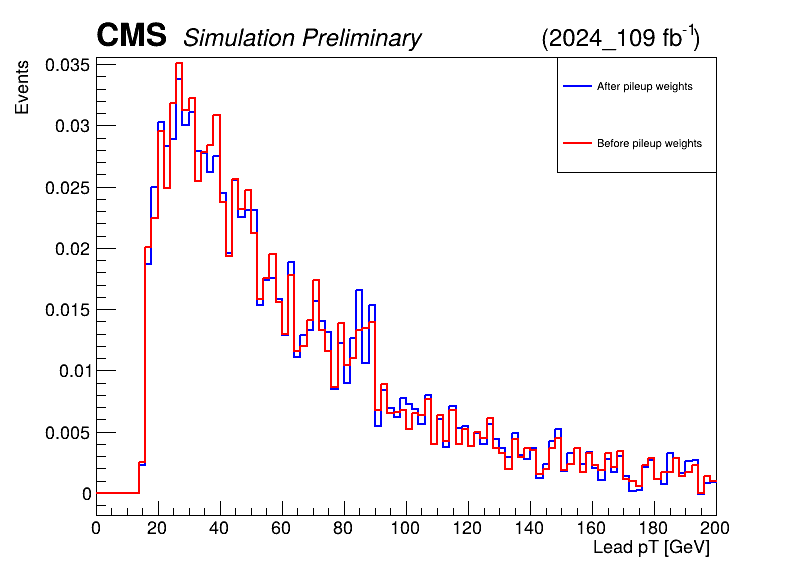

In [26]:
# --- Create histograms ---
h1 = ROOT.TH1F("h1", ";Lead pT [GeV]; Events", 100, 0, 200)
h2 = ROOT.TH1F("h2", ";Lead pT [GeV]; Events", 100, 0, 200)

h1.Sumw2()
h2.Sumw2()

# --- Fill ---
for v, wt1, wt2 in zip(a.pholead_pt, a.weight/ak.sum(a.weight), a.genWeight/ak.sum(a.genWeight)):
    h1.Fill(v, wt1)
    h2.Fill(v, wt2)

# --- Style ---
h1.SetLineColor(ROOT.kBlue)
h2.SetLineColor(ROOT.kRed)
h1.SetLineWidth(2)
h2.SetLineWidth(2)

# --- Draw ---
c = ROOT.TCanvas("c", "", 800, 600)
c.SetLeftMargin(0.12)
h1.Draw("HIST")
h2.Draw("HIST SAME")

# --- Legend ---
leg = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
leg.AddEntry(h1, "After pileup weights", "l")
leg.AddEntry(h2, "Before pileup weights", "l")
leg.Draw()

CMS_label(c)

c.SaveAs("overlay.png")
c.Draw()

Warning in <TROOT::Append>: Replacing existing TH1: h1 (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file overlay_pilup.png has been created


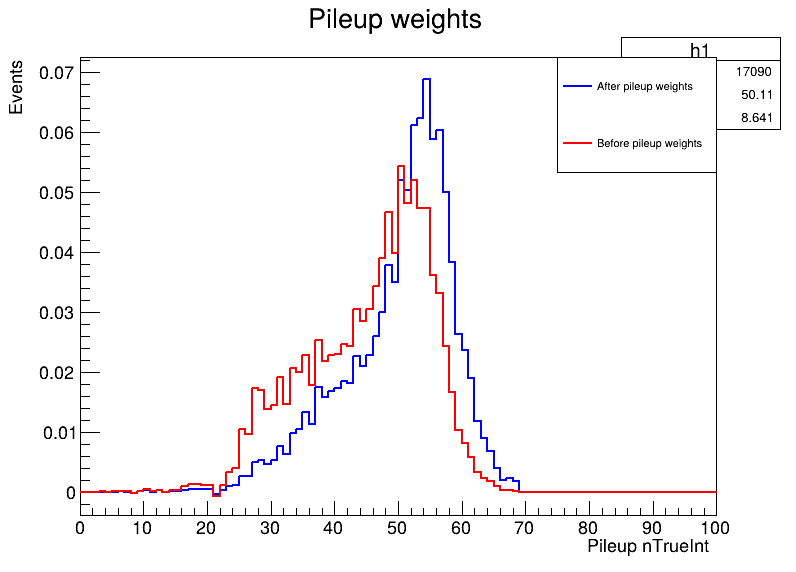

In [ ]:
# --- Create histograms ---
h1 = ROOT.TH1F("h1", "Pileup weights; Pileup nTrueInt; Events", 100, 0, 100)
h2 = ROOT.TH1F("h2", "Pileup weights; Pileup nTrueInt; Events", 100, 0, 100)

h1.Sumw2()
h2.Sumw2()

# --- Fill ---
for v, wt1, wt2 in zip(a.nTrueInt, a.weight/ak.sum(a.weight), a.genWeight/ak.sum(a.genWeight)):
    h1.Fill(v, wt1)
    h2.Fill(v, wt2)

# --- Style ---
h1.SetLineColor(ROOT.kBlue)
h2.SetLineColor(ROOT.kRed)
h1.SetLineWidth(2)
h2.SetLineWidth(2)


data_pu_file = "/eos/user/b/bbapi/CMSSW_14_0_15/src/pileup_histos/pileup_2024_Golden.root"

Era = "2024"

with uproot.open(data_pu_file) as f:
    data_vals, bin_edges = f["era2024/pileup"].to_numpy()
data_pdf = data_vals / np.sum(data_vals)

# --- Draw ---
c = ROOT.TCanvas("c", "", 800, 600)
h1.Draw("HIST")
h2.Draw("HIST SAME")

# --- Legend ---
leg = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
leg.AddEntry(h1, "After pileup weights", "l")
leg.AddEntry(h2, "Before pileup weights", "l")
leg.Draw()

c.SaveAs("overlay_pilup.png")
c.Draw()

In [4]:
import uproot 

data_pu_file = "/eos/user/b/bbapi/CMSSW_14_0_15/src/pileup_histos/pileup_2024_Golden.root"

Era = "2024"


with uproot.open(data_pu_file) as f:
    data_vals, bin_edges = f["era2024/pileup"].to_numpy()
data_pdf = data_vals / np.sum(data_vals)

Warning in <TROOT::Append>: Replacing existing TH1: h_mc (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_data (Potential memory leak).
Info in <TCanvas::Print>: png file pu_overlay.png has been created


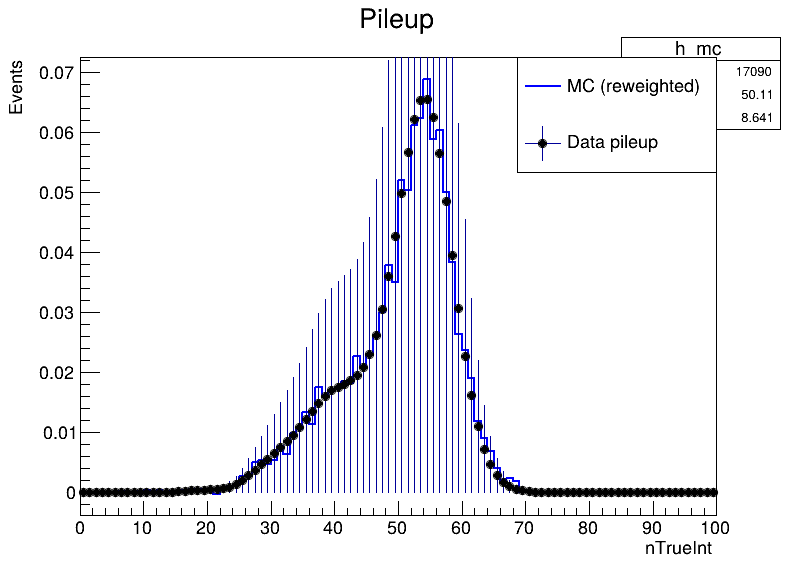

In [11]:
hist = uproot.open(data_pu_file)["era2024/pileup"]

ROOT.gStyle.SetErrorX(0)

# Get bin contents and edges
counts = hist.values()
edges  = hist.axes[0].edges()

# Normalize (important!)
counts = counts / np.sum(counts)

# Convert to bin centers
centers = 0.5 * (edges[:-1] + edges[1:])

# -------------------------------
# 2. Prepare MC (your arrays)
# -------------------------------
vals = ak.to_numpy(a.nTrueInt)
w_mc = ak.to_numpy(a.weight)

# Normalize MC weights
w_mc = w_mc / np.sum(w_mc)

# -------------------------------
# 3. Create ROOT histograms
# -------------------------------
h_mc   = ROOT.TH1F("h_mc", "Pileup; nTrueInt; Events", 100, 0, 100)
h_data = ROOT.TH1F("h_data", "Pileup; nTrueInt; Events", 100, 0, 100)

h_mc.Sumw2(False)
h_data.Sumw2(False)

# h_mc.Sumw2()
# h_data.Sumw2()

# Fill MC
for v, w in zip(vals, w_mc):
    h_mc.Fill(v, w)

# Fill DATA histogram manually from uproot
for c, x in zip(counts, centers):
    h_data.Fill(x, c)

# -------------------------------
# 4. Style
# -------------------------------
h_mc.SetLineColor(ROOT.kBlue)
h_mc.SetLineWidth(2)

h_data.SetMarkerStyle(20)
h_data.SetMarkerSize(1.0)
h_data.SetMarkerColor(ROOT.kBlack)



# -------------------------------
# 5. Draw overlay
# -------------------------------
c = ROOT.TCanvas("c", "", 800, 600)


# h_mc.Draw("HIST")
h_mc.Draw("HIST ]")  # suppress error bars explicitly
h_data.Draw("P SAME")   # markers

# Legend
leg = ROOT.TLegend(0.65, 0.7, 0.9, 0.9)
leg.AddEntry(h_mc, "MC (reweighted)", "l")
leg.AddEntry(h_data, "Data pileup", "lep")
leg.Draw()

c.SaveAs("pu_overlay.png")
c.Draw()

In [5]:
def CMS_label(pad,
              lumi="109 fb^{-1}",
              year="2024",
              energy="13.6 TeV",
              status="Simulation Preliminary",
              x=0.12,
              y=0.92):

    pad.cd()

    latex = ROOT.TLatex()
    latex.SetNDC()
    latex.SetTextAngle(0)
    latex.SetTextColor(ROOT.kBlack)

    # ---- CMS (bold) ----
    latex.SetTextFont(61)
    latex.SetTextSize(0.06)
    latex.DrawLatex(x, y, "CMS")

    # ---- Status (italic) ----
    if status != "":
        latex.SetTextFont(52)
        latex.SetTextSize(0.045)
        latex.DrawLatex(x + 0.11, y, status)

    # ---- Lumi text (right aligned) ----
    latex.SetTextFont(42)
    latex.SetTextSize(0.045)
    latex.SetTextAlign(31)
    lumi_text = f"({year}_{lumi})"
    latex.DrawLatex(0.88, y, lumi_text)

Warning in <TROOT::Append>: Replacing existing TH1: h_mc (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_data (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h2 (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file pu_overlay.png has been created


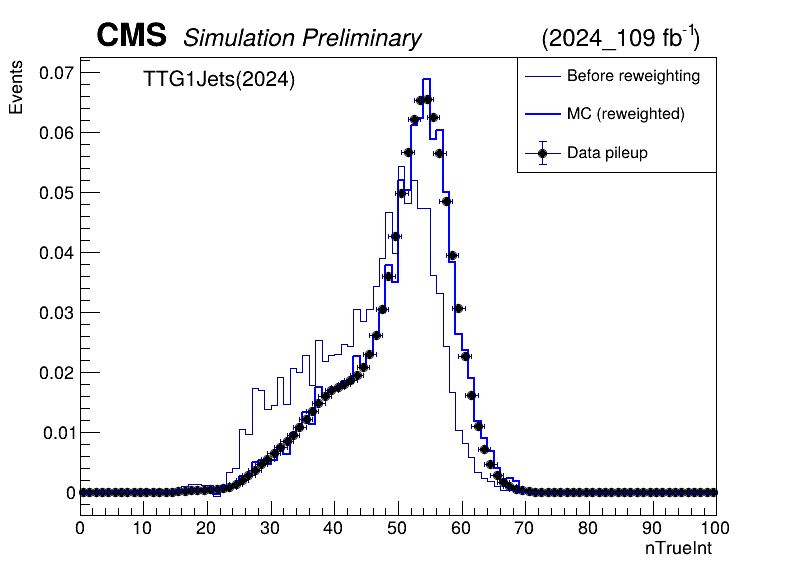

In [24]:
ROOT.gStyle.SetOptStat(0)

# -------------------------------
# 1. Load DATA pileup histogram
# -------------------------------
hist = uproot.open(data_pu_file)["era2024/pileup"]

counts = hist.values()
edges  = hist.axes[0].edges()

# -------------------------------
# 2. Prepare MC
# -------------------------------
vals = ak.to_numpy(a.nTrueInt)
w_mc = ak.to_numpy(a.weight)   # DO NOT normalize

# -------------------------------
# 3. Create ROOT histograms
# -------------------------------
h_mc   = ROOT.TH1F("h_mc", "; nTrueInt; Events", 100, 0, 100)
h_data = ROOT.TH1F("h_data", "; nTrueInt; Events", 100, 0, 100)
h2 = ROOT.TH1F("h2", "Pileup weights; Pileup nTrueInt; Events", 100, 0, 100)

h_mc.Sumw2()   # enable proper weighted errors
h2.Sumw2()

for v, wt2 in zip(a.nTrueInt,a.genWeight/ak.sum(a.genWeight)):
    h2.Fill(v, wt2)

# -------------------------------
# 4. Fill MC (correct way)
# -------------------------------
for v, w in zip(vals, w_mc):
    h_mc.Fill(v, w)

# -------------------------------
# 5. Fill DATA (correct way)
# -------------------------------
for i in range(len(counts)):
    h_data.SetBinContent(i+1, counts[i])
    h_data.SetBinError(i+1, np.sqrt(counts[i]))  # Poisson errors

# -------------------------------
# 6. Normalize AFTER filling
# -------------------------------
if h_mc.Integral() > 0:
    h_mc.Scale(1.0 / h_mc.Integral())

if h_data.Integral() > 0:
    h_data.Scale(1.0 / h_data.Integral())

# -------------------------------
# 7. Style
# -------------------------------
ROOT.gStyle.SetErrorX(1)

h_mc.SetLineColor(ROOT.kBlue)
h_mc.SetLineWidth(2)

h_data.SetMarkerStyle(20)
h_data.SetMarkerSize(1.0)
h_data.SetMarkerColor(ROOT.kBlack)

# -------------------------------
# 8. Draw
# -------------------------------
c = ROOT.TCanvas("c", "", 800, 600)

h_mc.Draw("HIST")        # clean line
h_data.Draw("E1 SAME")   # proper error bars
h2.Draw("HIST SAME")   # weights

# Legend
leg = ROOT.TLegend(0.65, 0.7, 0.9, 0.9)
leg.AddEntry(h2, "Before reweighting", "l")
leg.AddEntry(h_mc, "MC (reweighted)", "l")
leg.AddEntry(h_data, "Data pileup", "lep")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.18, 0.85, "TTG1Jets(2024)")

c.SaveAs("pu_overlay.png")
c.Draw()

In [2]:
import awkward as ak

nominal_directory = "/eos/user/b/bbapi/My_Analysis/2024_efficiency_study/NTuples_WH_2024_single_correction_check_Pileup/WH-2024M30/nominal/diphoton/"

a = ak.from_parquet(nominal_directory + "*.parquet")

raw_leadpt = a.pholead_pt_raw

raw_subleadpt = a.phosublead_pt_raw

In [3]:
def sort_by_event(file):
    order = np.argsort(ak.to_numpy(file.event))
    return file[order]

def load_common_triplet(file_nom, up_dir, down_dir):
    file_nom  = ak.from_parquet(file_nom)
    file_up   = ak.from_parquet(up_dir)
    file_down = ak.from_parquet(down_dir)

    idx_nom  = ak.to_numpy(file_nom.event)
    idx_up   = ak.to_numpy(file_up.event)
    idx_down = ak.to_numpy(file_down.event)

    # intersection: Nom ∩ Up ∩ Down 
    common_idx = np.intersect1d(idx_nom, idx_up, assume_unique=False)
    common_idx = np.intersect1d(common_idx, idx_down, assume_unique=False)

    # masks
    mask_nom  = np.isin(idx_nom,  common_idx)
    mask_up   = np.isin(idx_up,   common_idx)
    mask_down = np.isin(idx_down, common_idx)

    file_nom  = sort_by_event(file_nom[mask_nom])
    file_up   = sort_by_event(file_up[mask_up])
    file_down = sort_by_event(file_down[mask_down])

    return (
        file_nom,
        file_up,
        file_down,
    )


Info in <TCanvas::Print>: png file pu_overlay_WH.png has been created


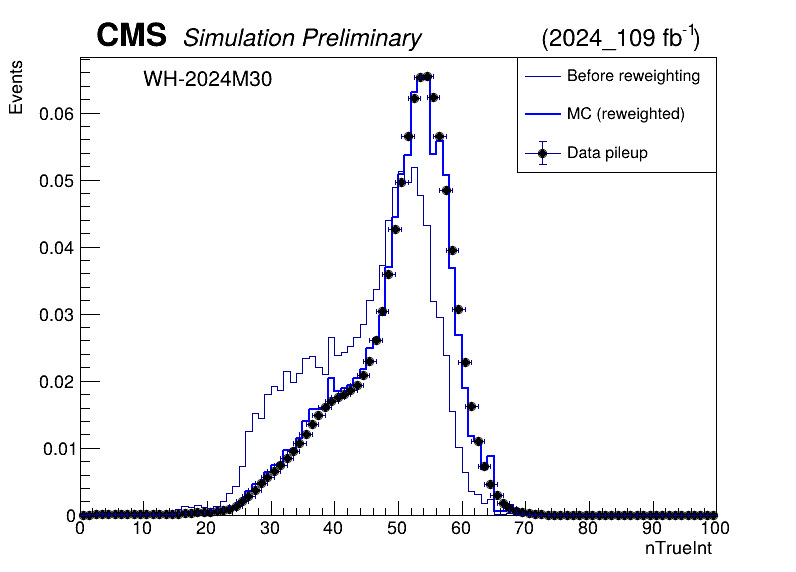

In [6]:
ROOT.gStyle.SetOptStat(0)

# -------------------------------
# 1. Load DATA pileup histogram
# -------------------------------
hist = uproot.open(data_pu_file)["era2024/pileup"]

counts = hist.values()
edges  = hist.axes[0].edges()

# -------------------------------
# 2. Prepare MC
# -------------------------------
vals = ak.to_numpy(a.nTrueInt)
w_mc = ak.to_numpy(a.weight)   # DO NOT normalize

# -------------------------------
# 3. Create ROOT histograms
# -------------------------------
h_mc   = ROOT.TH1F("h_mc", "; nTrueInt; Events", 100, 0, 100)
h_data = ROOT.TH1F("h_data", "; nTrueInt; Events", 100, 0, 100)
h2 = ROOT.TH1F("h2", "Pileup weights; Pileup nTrueInt; Events", 100, 0, 100)

h_mc.Sumw2()   # enable proper weighted errors
h2.Sumw2()

for v, wt2 in zip(a.nTrueInt,a.genWeight/ak.sum(a.genWeight)):
    h2.Fill(v, wt2)

# -------------------------------
# 4. Fill MC (correct way)
# -------------------------------
for v, w in zip(vals, w_mc):
    h_mc.Fill(v, w)

# -------------------------------
# 5. Fill DATA (correct way)
# -------------------------------
for i in range(len(counts)):
    h_data.SetBinContent(i+1, counts[i])
    h_data.SetBinError(i+1, np.sqrt(counts[i]))  # Poisson errors

# -------------------------------
# 6. Normalize AFTER filling
# -------------------------------
if h_mc.Integral() > 0:
    h_mc.Scale(1.0 / h_mc.Integral())

if h_data.Integral() > 0:
    h_data.Scale(1.0 / h_data.Integral())

# -------------------------------
# 7. Style
# -------------------------------
ROOT.gStyle.SetErrorX(1)

h_mc.SetLineColor(ROOT.kBlue)
h_mc.SetLineWidth(2)

h_data.SetMarkerStyle(20)
h_data.SetMarkerSize(1.0)
h_data.SetMarkerColor(ROOT.kBlack)

# -------------------------------
# 8. Draw
# -------------------------------
c = ROOT.TCanvas("c", "", 800, 600)

h_mc.Draw("HIST")        # clean line
h_data.Draw("E1 SAME")   # proper error bars
h2.Draw("HIST SAME")   # weights

# Legend
leg = ROOT.TLegend(0.65, 0.7, 0.9, 0.9)
leg.AddEntry(h2, "Before reweighting", "l")
leg.AddEntry(h_mc, "MC (reweighted)", "l")
leg.AddEntry(h_data, "Data pileup", "lep")
leg.Draw()

CMS_label(c)

latex = ROOT.TLatex()
latex.SetNDC()
latex.SetTextSize(0.04)
latex.SetTextFont(42)
latex.DrawLatex(0.18, 0.85, "WH-2024M30")

c.SaveAs("pu_overlay_WH.png")
c.Draw()

In [37]:
def get_diphoton_mass(pt1, eta1, phi1, pt2, eta2, phi2):
    deta = eta1 - eta2
    
    # Proper Δφ wrapping
    dphi = (phi1 - phi2 + np.pi) % (2*np.pi) - np.pi
    
    m2 = 2 * pt1 * pt2 * (np.cosh(deta) - np.cos(dphi))
    
    return np.sqrt(m2)

In [44]:
mass_raw = get_diphoton_mass(
    nom.pholead_pt_raw,
    nom.pholead_eta,
    nom.pholead_phi,
    nom.phosublead_pt_raw,
    nom.phosublead_eta,
    nom.phosublead_phi
)

In [45]:
mass_raw

<Array [104, 55.4, 132, 82.4, ..., 29.5, 64.6, 45.6] type='16846 * ?float32'>

In [46]:
nom.mass

<Array [104, 55.4, 133, 81.8, ..., 29.5, 66.2, 42.1] type='16846 * ?float64'>

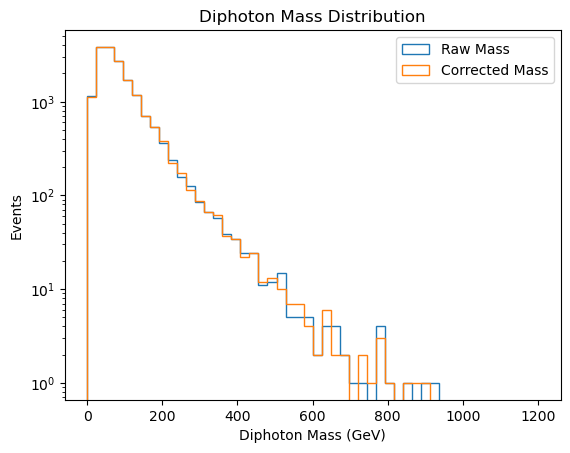

In [52]:
plt.hist(mass_raw, bins=50, range = (0, 1200),histtype='step', label="Raw Mass")
plt.hist(nom.mass, bins=50, range = (0, 1200), histtype='step', label="Corrected Mass")
plt.xlabel("Diphoton Mass (GeV)")
plt.ylabel("Events")
plt.legend()
plt.title("Diphoton Mass Distribution")
plt.yscale('log')
plt.yscale('log')
plt.show()

In [43]:
nom, up, down = load_common_triplet(nominal_directory + "*.parquet", up_dir + "*.parquet", down_dir + "*.parquet" )

In [14]:
nom.pholead_pt

<Array [119, 33.4, 383, 90.5, ..., 41.9, 37.6, 31.1] type='16954 * ?float32'>

In [16]:
up.phosublead_pt

<Array [21.4, 20.1, 28.1, 17.8, ..., 24.1, 18.8, 24] type='16954 * ?float32'>

In [19]:
np.unique(down.pholead_pt/nom.pholead_pt)

<Array [0.99, 0.99, 0.99, 0.991, ..., 0.999, 0.999, 1, 1] type='32 * ?float32'>

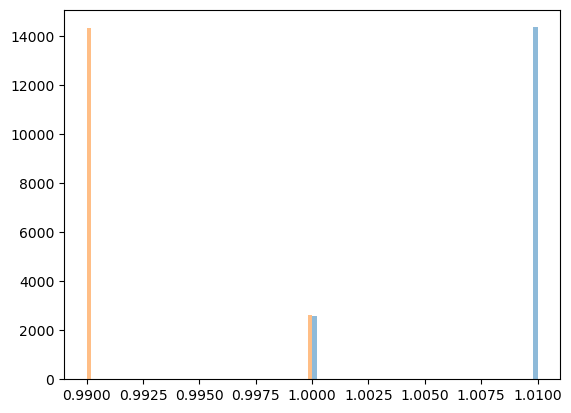

In [22]:
plt.hist(up.pholead_pt/nom.pholead_pt, bins=50, alpha=0.5, label="Up");
plt.hist(down.pholead_pt/nom.pholead_pt, bins=50, alpha=0.5, label="Down");

In [33]:
import numpy as np

# Convert to numpy (if awkward arrays)
up_arr   = np.array(up.pholead_pt)
down_arr = np.array(down.pholead_pt)
nom_arr  = np.array(nom.pholead_pt)

# Avoid division by zero
mask = nom_arr != 0

ratio_up   = up_arr[mask] / nom_arr[mask]
ratio_down = down_arr[mask] / nom_arr[mask]

# Create histograms
h_up = ROOT.TH1F("h_up", "Up/Nom;Ratio;Entries", 20, 0.985, 1.015)
h_down = ROOT.TH1F("h_down", "Down/Nom;Ratio;Entries", 20, 0.985, 1.015)

# Fill histograms
for val in ratio_up:
    h_up.Fill(val)

for val in ratio_down:
    h_down.Fill(val)

# Style (simulate matplotlib alpha)
h_up.SetLineColor(ROOT.kRed)
h_up.SetFillColorAlpha(ROOT.kRed, 0.4)

h_down.SetLineColor(ROOT.kBlue)
h_down.SetFillColorAlpha(ROOT.kBlue, 0.4)

# Draw
c = ROOT.TCanvas("c", "c", 800, 600)
h_up.Draw("HIST")
h_down.Draw("HIST SAME")

# Legend
leg = ROOT.TLegend(0.7, 0.7, 0.9, 0.9)
leg.AddEntry(h_up, "Up", "f")
leg.AddEntry(h_down, "Down", "f")
leg.Draw()

c.SaveAs("ratio_plot.png")

Warning in <TROOT::Append>: Replacing existing TH1: h_up (Potential memory leak).
Warning in <TROOT::Append>: Replacing existing TH1: h_down (Potential memory leak).
Warning in <TCanvas::Constructor>: Deleting canvas with same name: c
Info in <TCanvas::Print>: png file ratio_plot.png has been created


In [3]:
raw_leadpt

<Array [148, 59.9, 208, 161, ..., 20.3, 214, 109, 32.6] type='17114 * ?float32'>

In [5]:
up_leadpt

<Array [146, 59.9, 206, 157, ..., 20.3, 217, 111, 32.6] type='17112 * ?float64'>

In [6]:
def to_np(arr):
    return ak.to_numpy(arr)

# -------- Common binning --------
all_vals = np.concatenate([
    raw_leadpt, corrected_leadpt, up_leadpt, down_leadpt,
    raw_subleadpt, corrected_subleadpt, up_subleadpt, down_subleadpt
])

xmin, xmax = 10, 200
bins = 100

# -------- Helper to create + fill --------
def make_hist(name, arr):
    # Ensure correct dtype + contiguous memory
    arr = np.asarray(arr, dtype=np.float64)

    h = ROOT.TH1F(name, "", bins, xmin, xmax)

    # weights
    weights = np.ones(len(arr), dtype=np.float64)

    # Use FillN properly
    h.FillN(len(arr), arr, weights)

    if h.Integral() > 0:
        h.Scale(1.0 / h.Integral())

    h.SetLineWidth(2)
    return h


def make_ratio(h_num, h_den, name):
    h_ratio = h_num.Clone(name)
    h_ratio.Divide(h_den)
    h_ratio.SetStats(0)
    return h_ratio

# -------- LEAD HISTOGRAMS --------
h_raw_lead  = make_hist("h_raw_lead", to_np(raw_leadpt))
h_corr_lead = make_hist("h_corr_lead", to_np(corrected_leadpt))
h_up_lead   = make_hist("h_up_lead", to_np(up_leadpt))
h_down_lead = make_hist("h_down_lead", to_np(down_leadpt))

# Styling
h_raw_lead.SetLineColor(ROOT.kBlack)

h_corr_lead.SetLineColor(ROOT.kGreen+2)

h_up_lead.SetLineColor(ROOT.kRed)
h_up_lead.SetLineStyle(2)

h_down_lead.SetLineColor(ROOT.kBlue)
h_down_lead.SetLineStyle(2)

# -------- SUBLEAD HISTOGRAMS --------
h_raw_sub  = make_hist("h_raw_sub", to_np(raw_subleadpt))
h_corr_sub = make_hist("h_corr_sub", to_np(corrected_subleadpt))
h_up_sub   = make_hist("h_up_sub", to_np(up_subleadpt))
h_down_sub = make_hist("h_down_sub", to_np(down_subleadpt))

# Styling
h_raw_sub.SetLineColor(ROOT.kBlack)

h_corr_sub.SetLineColor(ROOT.kGreen+2)

h_up_sub.SetLineColor(ROOT.kRed)
h_up_sub.SetLineStyle(2)

h_down_sub.SetLineColor(ROOT.kBlue)
h_down_sub.SetLineStyle(2)

# # ===============================
# # Canvas 1: LEAD
# # ===============================
# c1 = ROOT.TCanvas("c1", "Lead pT", 800, 600)

# c1.SetLogy()

# h_raw_lead.SetTitle("Lead Photon pT; pT; Normalized Entries")

# h_raw_lead.Draw("HIST")
# h_corr_lead.Draw("HIST SAME")
# h_up_lead.Draw("HIST SAME")
# h_down_lead.Draw("HIST SAME")

# leg1 = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)
# leg1.AddEntry(h_raw_lead,  "Raw", "l")
# leg1.AddEntry(h_corr_lead, "Corrected", "l")
# leg1.AddEntry(h_up_lead,   "Up", "l")
# leg1.AddEntry(h_down_lead, "Down", "l")
# leg1.Draw()

# c1.SetGrid()
# c1.SaveAs("lead_overlay.png")

# # ===============================
# # Canvas 2: SUBLEAD
# # ===============================
# c2 = ROOT.TCanvas("c2", "Sublead pT", 800, 600)

# c2.SetLogy()

# h_raw_sub.SetTitle("Sublead Photon pT; pT; Normalized Entries")

# h_raw_sub.Draw("HIST")
# h_corr_sub.Draw("HIST SAME")
# h_up_sub.Draw("HIST SAME")
# h_down_sub.Draw("HIST SAME")

# leg2 = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)
# leg2.AddEntry(h_raw_sub,  "Raw", "l")
# leg2.AddEntry(h_corr_sub, "Corrected", "l")
# leg2.AddEntry(h_up_sub,   "Up", "l")
# leg2.AddEntry(h_down_sub, "Down", "l")
# leg2.Draw()

# c2.SetGrid()
# c2.SaveAs("sublead_overlay.png")

c1 = ROOT.TCanvas("c1", "Lead pT", 800, 800)

pad1 = ROOT.TPad("pad1", "", 0, 0.30, 1, 1.00)
pad2 = ROOT.TPad("pad2", "", 0, 0.00, 1, 0.30)

pad1.SetBottomMargin(0.02)
pad2.SetTopMargin(0.05)
pad2.SetBottomMargin(0.30)

pad1.Draw()
pad2.Draw()


pad1.cd()
ROOT.gPad.SetLogy()

h_raw_lead.SetTitle("Lead Photon pT; pT; Normalized Entries")

h_raw_lead.Draw("HIST")
h_corr_lead.Draw("HIST SAME")
h_up_lead.Draw("HIST SAME")
h_down_lead.Draw("HIST SAME")

leg1 = ROOT.TLegend(0.6, 0.7, 0.88, 0.88)
leg1.AddEntry(h_raw_lead,  "Raw", "l")
leg1.AddEntry(h_corr_lead, "Nominal", "l")
leg1.AddEntry(h_up_lead,   "Up", "l")
leg1.AddEntry(h_down_lead, "Down", "l")
leg1.Draw()


pad2.cd()

# ---- Ratios
h_ratio_nom = make_ratio(h_corr_lead, h_raw_lead, "ratio_nom")
h_ratio_up  = make_ratio(h_up_lead, h_corr_lead, "ratio_up")
h_ratio_down= make_ratio(h_down_lead, h_corr_lead, "ratio_down")

# ---- Style
h_ratio_nom.SetMarkerStyle(21)
h_ratio_nom.SetMarkerColor(ROOT.kGreen+2)
h_ratio_nom.SetLineColor(ROOT.kGreen+2)

h_ratio_up.SetMarkerStyle(20)
h_ratio_up.SetMarkerColor(ROOT.kRed)
h_ratio_up.SetLineColor(ROOT.kRed)

h_ratio_down.SetMarkerStyle(24)
h_ratio_down.SetMarkerColor(ROOT.kBlue)
h_ratio_down.SetLineColor(ROOT.kBlue)

# Axis formatting
h_ratio_up.SetMinimum(0.5)
h_ratio_up.SetMaximum(1.5)

h_ratio_up.GetYaxis().SetTitle("Ratio")
h_ratio_up.GetYaxis().SetTitleSize(0.10)
h_ratio_up.GetYaxis().SetLabelSize(0.08)

h_ratio_up.GetXaxis().SetTitle("p_{T} [GeV]")
h_ratio_up.GetXaxis().SetTitleSize(0.12)
h_ratio_up.GetXaxis().SetLabelSize(0.10)

# Draw
h_ratio_up.Draw("P")
h_ratio_down.Draw("P SAME")
h_ratio_nom.Draw("P SAME")

# Unity line
line = ROOT.TLine(xmin, 1.0, xmax, 1.0)
line.SetLineStyle(2)
line.Draw()

# Legend
leg_ratio = ROOT.TLegend(0.65, 0.7, 0.88, 0.9)
leg_ratio.SetBorderSize(0)
leg_ratio.SetFillStyle(0)
leg_ratio.AddEntry(h_ratio_nom,  "Nom / Raw", "p")
leg_ratio.AddEntry(h_ratio_up,   "Up / Nom", "p")
leg_ratio.AddEntry(h_ratio_down, "Down / Nom", "p")
leg_ratio.Draw()

c1.SaveAs("lead_ratio.png")

Info in <TCanvas::Print>: png file lead_ratio.png has been created
